# <center> Графы для рекомендательных систем </center>

## Введение

Рассмотрим на примере GraphSAGE (Graph Sample and Aggregate) - это архитектура для обучения представлений узлов в графах. В контексте рекомендательных систем мы можем моделировать взаимодействия пользователей и айтемов как граф, где:
- Узлы представляют пользователей и айтемы
- Рёбра представляют взаимодействия (просмотры, клики и т.д.)

**Hamilton, W., Ying, Z. and Leskovec, J., 2017. Inductive representation learning on large graphs. Advances in neural information processing systems, 30.**

Статья: https://arxiv.org/abs/1706.02216

In [26]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sn
import random
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

sn.set()

torch.set_num_threads(1)

In [27]:
torch.__version__

'2.10.0'

In [28]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    
seed_everything()

## GraphSAGE архитектура

Основная идея GraphSAGE:
1. **Sample** - сэмплирование соседей узла
2. **Aggregate** - агрегация информации от соседей
3. **Update** - обновление представления узла

Формула для обновления представления узла $v$ на слое $k$:

$$h^k_{\mathcal{N}(v)} = \text{AGGREGATE}_k(\{h^{k-1}_u, \forall u \in \mathcal{N}(v)\})$$

$$h^k_v = \sigma(W^k \cdot \text{CONCAT}(h^{k-1}_v, h^k_{\mathcal{N}(v)}))$$

где $\mathcal{N}(v)$ - множество соседей узла $v$, $W^k$ - обучаемая матрица весов.

## Загрузка данных KION

In [29]:
# Загружаем датасет
interactions = pd.read_csv('../../interactions.csv')
items = pd.read_csv('../../items.csv')
users = pd.read_csv('../../users.csv')

print(f"Interactions shape: {interactions.shape}")
print(f"Items shape: {items.shape}")
print(f"Users shape: {users.shape}")

Interactions shape: (5476251, 5)
Items shape: (15963, 14)
Users shape: (840197, 5)


In [30]:
interactions.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [31]:
items.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [32]:
users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


## Препроцессинг данных

In [33]:
# Сэмплируем пользователей для ускорения обучения
sampled_users = np.random.choice(interactions.user_id.unique(), size=5000, replace=False)
interactions_sampled = interactions[interactions.user_id.isin(sampled_users)].copy()

print(f"Sampled interactions: {interactions_sampled.shape[0]}")
print(f"Unique users: {interactions_sampled.user_id.nunique()}")
print(f"Unique items: {interactions_sampled.item_id.nunique()}")

Sampled interactions: 27887
Unique users: 5000
Unique items: 4101


In [34]:
# Фильтруем пользователей и айтемы с минимальным числом взаимодействий
def filter_data(df, min_user_interactions=5, min_item_interactions=5):
    while True:
        user_counts = df.user_id.value_counts()
        item_counts = df.item_id.value_counts()
        
        valid_users = user_counts[user_counts >= min_user_interactions].index
        valid_items = item_counts[item_counts >= min_item_interactions].index
        
        df_filtered = df[df.user_id.isin(valid_users) & df.item_id.isin(valid_items)]
        
        if len(df_filtered) == len(df):
            break
        df = df_filtered
    
    return df

interactions_filtered = filter_data(interactions_sampled, min_user_interactions=5, min_item_interactions=5)

print(f"Filtered interactions: {interactions_filtered.shape[0]}")
print(f"Unique users: {interactions_filtered.user_id.nunique()}")
print(f"Unique items: {interactions_filtered.item_id.nunique()}")

Filtered interactions: 15515
Unique users: 1277
Unique items: 975


In [35]:
# Создаём маппинги для пользователей и айтемов
unique_users = interactions_filtered.user_id.unique()
unique_items = interactions_filtered.item_id.unique()

user2id = {user: idx for idx, user in enumerate(unique_users)}
item2id = {item: idx + len(unique_users) for idx, item in enumerate(unique_items)}

id2user = {v: k for k, v in user2id.items()}
id2item = {v: k for k, v in item2id.items()}

# Применяем маппинги
interactions_filtered['user_idx'] = interactions_filtered.user_id.map(user2id)
interactions_filtered['item_idx'] = interactions_filtered.item_id.map(item2id)

n_users = len(unique_users)
n_items = len(unique_items)
n_nodes = n_users + n_items

print(f"Number of user nodes: {n_users}")
print(f"Number of item nodes: {n_items}")
print(f"Total nodes: {n_nodes}")

Number of user nodes: 1277
Number of item nodes: 975
Total nodes: 2252


## Построение графа

Создадим двудольный граф пользователь-айтем. В GraphSAGE мы будем агрегировать информацию от соседей каждого узла.

In [36]:
# Создаём словарь соседей для каждого узла
from collections import defaultdict

neighbors = defaultdict(set)

for _, row in interactions_filtered.iterrows():
    user_idx = row['user_idx']
    item_idx = row['item_idx']
    
    # Добавляем рёбра в обе стороны (неориентированный граф)
    neighbors[user_idx].add(item_idx)
    neighbors[item_idx].add(user_idx)

# Преобразуем в списки для удобства
neighbors = {k: list(v) for k, v in neighbors.items()}

print(f"Graph constructed with {len(neighbors)} nodes")
print(f"Average degree: {np.mean([len(v) for v in neighbors.values()]):.2f}")

Graph constructed with 2252 nodes
Average degree: 13.78


## Train/Validation/Test сплит

In [37]:
# Сортируем по времени
interactions_filtered = interactions_filtered.sort_values('last_watch_dt')

# Разбиваем пользователей на train/val/test
np.random.seed(42)
user_ids = interactions_filtered.user_idx.unique()
np.random.shuffle(user_ids)

n_test = int(0.1 * len(user_ids))
n_val = int(0.1 * len(user_ids))

test_users = set(user_ids[:n_test])
val_users = set(user_ids[n_test:n_test + n_val])
train_users = set(user_ids[n_test + n_val:])

print(f"Train users: {len(train_users)}")
print(f"Val users: {len(val_users)}")
print(f"Test users: {len(test_users)}")

Train users: 1023
Val users: 127
Test users: 127


In [38]:
# Для каждого пользователя из val/test разбиваем его взаимодействия на train (80%) и test (20%)
def split_user_interactions(user_interactions, test_ratio=0.2):
    n_test = max(1, int(len(user_interactions) * test_ratio))
    return user_interactions[:-n_test], user_interactions[-n_test:]

train_edges = []
val_edges_tr = []
val_edges_te = []
test_edges_tr = []
test_edges_te = []

for user_idx in user_ids:
    user_interactions = interactions_filtered[interactions_filtered.user_idx == user_idx]
    
    if user_idx in train_users:
        # Все взаимодействия идут в train
        for _, row in user_interactions.iterrows():
            train_edges.append((row['user_idx'], row['item_idx']))
    
    elif user_idx in val_users:
        # Разбиваем на train и test
        train_part, test_part = split_user_interactions(user_interactions)
        
        for _, row in train_part.iterrows():
            val_edges_tr.append((row['user_idx'], row['item_idx']))
        
        for _, row in test_part.iterrows():
            val_edges_te.append((row['user_idx'], row['item_idx']))
    
    elif user_idx in test_users:
        # Разбиваем на train и test
        train_part, test_part = split_user_interactions(user_interactions)
        
        for _, row in train_part.iterrows():
            test_edges_tr.append((row['user_idx'], row['item_idx']))
        
        for _, row in test_part.iterrows():
            test_edges_te.append((row['user_idx'], row['item_idx']))

print(f"Train edges: {len(train_edges)}")
print(f"Val train edges: {len(val_edges_tr)}, Val test edges: {len(val_edges_te)}")
print(f"Test train edges: {len(test_edges_tr)}, Test test edges: {len(test_edges_te)}")

Train edges: 12442
Val train edges: 1215, Val test edges: 255
Test train edges: 1327, Test test edges: 276


## Имплементация GraphSAGE from scratch

### Aggregator функции

GraphSAGE поддерживает различные агрегаторы:
- **Mean aggregator**: усредняет embeddings соседей
- **LSTM aggregator**: использует LSTM для агрегации
- **Pooling aggregator**: применяет max/mean pooling

Мы реализуем Mean aggregator как самый простой и эффективный.

In [39]:
class MeanAggregator(nn.Module):
    """
    Mean aggregator для GraphSAGE
    """
    def __init__(self, input_dim, output_dim, activation=F.relu, bias=True):
        super(MeanAggregator, self).__init__()
        
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.activation = activation
        
        # Веса для самого узла и для агрегированных соседей
        self.weight_self = nn.Linear(input_dim, output_dim, bias=bias)
        self.weight_neigh = nn.Linear(input_dim, output_dim, bias=bias)
    
    def forward(self, self_embedding, neighbor_embeddings):
        """
        Args:
            self_embedding: (batch_size, input_dim) - embeddings узлов
            neighbor_embeddings: (batch_size, num_neighbors, input_dim) - embeddings соседей
        
        Returns:
            aggregated: (batch_size, output_dim) - обновлённые embeddings
        """
        # Усредняем embeddings соседей
        if neighbor_embeddings.shape[1] > 0:
            aggregated_neigh = torch.mean(neighbor_embeddings, dim=1)  # (batch_size, input_dim)
        else:
            aggregated_neigh = torch.zeros_like(self_embedding)
        
        # Применяем линейные преобразования
        self_out = self.weight_self(self_embedding)
        neigh_out = self.weight_neigh(aggregated_neigh)
        
        # Комбинируем и применяем активацию
        output = self_out + neigh_out
        
        if self.activation is not None:
            output = self.activation(output)
        
        # L2 нормализация
        output = F.normalize(output, p=2, dim=1)
        
        return output

### GraphSAGE Layer

In [40]:
class GraphSAGELayer(nn.Module):

    def __init__(self, input_dim, output_dim, aggregator='mean'):
        super().__init__()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.aggregator = aggregator

        self.linear = nn.Linear(
            input_dim * 2,
            output_dim
        )

    def forward(
        self,
        node_embeddings,
        neighbor_indices,
        self_indices
    ):

        device = node_embeddings.device

        self_embeds = []
        neigh_agg = []

        for idx, neighs in zip(self_indices, neighbor_indices):

            # self embedding
            self_embeds.append(
                node_embeddings[idx]
            )

            # neighbors
            if len(neighs) > 0:

                neigh_embed = node_embeddings[neighs]

                if self.aggregator == 'mean':

                    agg = neigh_embed.mean(dim=0)

                elif self.aggregator == 'pool':

                    agg = torch.max(
                        neigh_embed,
                        dim=0
                    )[0]

                else:

                    raise ValueError(
                        "Unsupported aggregator"
                    )

            else:

                agg = torch.zeros(
                    node_embeddings.shape[1],
                    device=device
                )

            neigh_agg.append(agg)

        self_embeds = torch.stack(self_embeds)
        neigh_agg = torch.stack(neigh_agg)

        combined = torch.cat(
            [self_embeds, neigh_agg],
            dim=1
        )

        return self.linear(combined)

### GraphSAGE модель

In [41]:
class GraphSAGE(nn.Module):
    """
    GraphSAGE модель для рекомендательных систем
    """
    def __init__(self, n_nodes, embedding_dim, hidden_dims, num_neighbors_list, aggregator='mean'):
        """
        Args:
            n_nodes: общее количество узлов (пользователи + айтемы)
            embedding_dim: размерность начальных embeddings
            hidden_dims: список размерностей скрытых слоёв
            num_neighbors_list: список количества соседей для сэмплирования на каждом слое
            aggregator: тип агрегатора ('mean', 'lstm', 'pool')
        """
        super(GraphSAGE, self).__init__()
        
        self.n_nodes = n_nodes
        self.embedding_dim = embedding_dim
        self.num_neighbors_list = num_neighbors_list
        self.num_layers = len(num_neighbors_list)
        
        # Начальные embeddings для всех узлов
        self.node_embeddings = nn.Embedding(n_nodes, embedding_dim)
        nn.init.xavier_uniform_(self.node_embeddings.weight)
        
        # GraphSAGE слои
        self.layers = nn.ModuleList()
        input_dim = embedding_dim
        
        for hidden_dim in hidden_dims:
            self.layers.append(GraphSAGELayer(input_dim, hidden_dim, aggregator))
            input_dim = hidden_dim
        
        self.output_dim = hidden_dims[-1]
    
    def sample_neighbors(self, nodes, neighbors_dict, num_samples):
        """
        Сэмплирование соседей для узлов
        
        Args:
            nodes: список индексов узлов
            neighbors_dict: словарь {node_id: [neighbor_ids]}
            num_samples: количество соседей для сэмплирования
        
        Returns:
            sampled_neighbors: список списков индексов соседей
        """
        sampled_neighbors = []
        
        for node in nodes:
            node_id = node.item() if torch.is_tensor(node) else node
            
            if node_id in neighbors_dict:
                neighs = neighbors_dict[node_id]
                
                if len(neighs) >= num_samples:
                    sampled = np.random.choice(neighs, num_samples, replace=False)
                else:
                    sampled = np.random.choice(neighs, num_samples, replace=True)
                
                sampled_neighbors.append(sampled.tolist())
            else:
                sampled_neighbors.append([])
        
        return sampled_neighbors
    
    def forward(self, nodes, neighbors_dict):

        device = nodes.device

        current_nodes = nodes.cpu().numpy()

        layer_nodes = [current_nodes]
        layer_sampled_neighbors = []

        # --- Sampling ---

        for num_samples in self.num_neighbors_list:

            sampled_neighs = self.sample_neighbors(
                current_nodes,
                neighbors_dict,
                num_samples
            )

            layer_sampled_neighbors.insert(
                0,
                sampled_neighs
            )

            all_neighs = set().union(
                *sampled_neighs
            )

            current_nodes = list(
                set(current_nodes) | all_neighs
            )

            layer_nodes.insert(
                0,
                current_nodes
            )

        # --- Initial embeddings ---

        deepest_nodes = layer_nodes[0]

        deepest_indices = torch.tensor(
            deepest_nodes,
            dtype=torch.long,
            device=device
        )

        h = self.node_embeddings(
            deepest_indices
        )

        # --- Message passing ---

        for layer_idx, layer in enumerate(self.layers):

            nodes_prev = layer_nodes[layer_idx]
            nodes_curr = layer_nodes[layer_idx + 1]

            neighbors_in_layer = (
                layer_sampled_neighbors[layer_idx]
            )

            node_to_idx = {
                node: idx
                for idx, node in enumerate(nodes_prev)
            }

            mapped_neighbors = []

            for node_pos, node in enumerate(nodes_curr):

                neighs = neighbors_in_layer[node_pos]

                mapped = [
                    node_to_idx[n]
                    for n in neighs
                    if n in node_to_idx
                ]

                mapped_neighbors.append(mapped)

            # КЛЮЧЕВОЕ: индексы self-узлов

            self_indices = [
                node_to_idx[node]
                for node in nodes_curr
            ]

            h = layer(
                h,
                mapped_neighbors,
                self_indices
            )

        batch_size = len(nodes)

        return h[:batch_size]
    
    def encode_users_items(self, user_indices, item_indices, neighbors_dict):
        """
        Получает embeddings для пользователей и айтемов
        """
        user_embeddings = self.forward(user_indices, neighbors_dict)
        item_embeddings = self.forward(item_indices, neighbors_dict)
        return user_embeddings, item_embeddings
    
    def predict(self, user_indices, item_indices, neighbors_dict):
        """
        Предсказывает скоры для пар (user, item)
        """
        user_embeddings, item_embeddings = self.encode_users_items(user_indices, item_indices, neighbors_dict)
        scores = torch.sum(user_embeddings * item_embeddings, dim=1)
        return scores

## Функция потерь и обучение

Будем использовать BPR (Bayesian Personalized Ranking) loss:

$$\mathcal{L} = -\sum_{(u,i,j) \in D} \log \sigma(\hat{y}_{ui} - \hat{y}_{uj})$$

где $\hat{y}_{ui}$ - предсказанный скор для положительного примера (пользователь $u$, айтем $i$),  
$\hat{y}_{uj}$ - предсказанный скор для отрицательного примера (пользователь $u$, айтем $j$).

In [42]:
class BPRLoss(nn.Module):
    """
    Bayesian Personalized Ranking Loss
    """
    def __init__(self):
        super(BPRLoss, self).__init__()
    
    def forward(self, pos_scores, neg_scores):
        """
        Args:
            pos_scores: (batch_size,) - скоры для положительных примеров
            neg_scores: (batch_size,) - скоры для отрицательных примеров
        """
        loss = -torch.mean(F.logsigmoid(pos_scores - neg_scores))
        return loss

In [43]:
# Dataset для обучения
class RecSysDataset(Dataset):
    def __init__(self, edges, n_users, n_items, num_negatives=1):
        """
        Args:
            edges: список кортежей (user_idx, item_idx)
            n_users: количество пользователей
            n_items: количество айтемов
            num_negatives: количество негативных примеров на один позитивный
        """
        self.edges = edges
        self.n_users = n_users
        self.n_items = n_items
        self.num_negatives = num_negatives
        
        # Создаём множество позитивных примеров для быстрой проверки
        self.positive_set = set(edges)
        
        # Все айтемы
        self.all_items = list(range(n_users, n_users + n_items))
    
    def __len__(self):
        return len(self.edges)
    
    def __getitem__(self, idx):
        user, pos_item = self.edges[idx]
        
        # Сэмплируем негативные примеры
        neg_items = []
        while len(neg_items) < self.num_negatives:
            neg_item = np.random.choice(self.all_items)
            if (user, neg_item) not in self.positive_set:
                neg_items.append(neg_item)
        
        return user, pos_item, neg_items[0]  # Возвращаем один негативный пример

## Метрики качества

In [44]:
def recall_at_k(model, test_edges_tr, test_edges_te, neighbors_dict, n_users, n_items, k=20, batch_size=256):
    """
    Вычисляет Recall@K
    """
    model.eval()
    
    # Группируем test edges по пользователям
    user_test_items = defaultdict(set)
    for user, item in test_edges_te:
        user_test_items[user].add(item)
    
    recalls = []
    
    with torch.no_grad():
        for user in user_test_items.keys():
            # Получаем все айтемы, которые пользователь видел в train
            train_items = set([item for u, item in test_edges_tr if u == user])
            
            # Все айтемы
            all_items = torch.arange(n_users, n_users + n_items)
            
            # Получаем предсказания для всех айтемов
            user_tensor = torch.tensor([user] * len(all_items))
            
            scores = model.predict(user_tensor, all_items, neighbors_dict)
            
            # Исключаем айтемы из train
            for item in train_items:
                scores[item - n_users] = -float('inf')
            
            # Топ-K айтемов
            _, top_items_idx = torch.topk(scores, k)
            top_items = set((all_items[top_items_idx]).cpu().numpy())
            
            # Вычисляем recall
            test_items = user_test_items[user]
            hits = len(top_items & test_items)
            recall = hits / min(len(test_items), k)
            recalls.append(recall)
    
    return np.mean(recalls)


def ndcg_at_k(model, test_edges_tr, test_edges_te, neighbors_dict, n_users, n_items, k=20):
    """
    Вычисляет NDCG@K
    """
    model.eval()
    
    user_test_items = defaultdict(set)
    for user, item in test_edges_te:
        user_test_items[user].add(item)
    
    ndcgs = []
    
    with torch.no_grad():
        for user in user_test_items.keys():
            train_items = set([item for u, item in test_edges_tr if u == user])
            
            all_items = torch.arange(n_users, n_users + n_items)
            user_tensor = torch.tensor([user] * len(all_items))
            
            scores = model.predict(user_tensor, all_items, neighbors_dict)
            
            for item in train_items:
                scores[item - n_users] = -float('inf')
            
            _, top_items_idx = torch.topk(scores, k)
            top_items = (all_items[top_items_idx]).cpu().numpy()
            
            # Вычисляем NDCG
            test_items = user_test_items[user]
            dcg = 0
            idcg = 0
            
            for i, item in enumerate(top_items):
                if item in test_items:
                    dcg += 1 / np.log2(i + 2)
            
            for i in range(min(len(test_items), k)):
                idcg += 1 / np.log2(i + 2)
            
            ndcg = dcg / idcg if idcg > 0 else 0
            ndcgs.append(ndcg)
    
    return np.mean(ndcgs)

## Обучение модели

In [45]:
# Гиперпараметры
EMBEDDING_DIM = 64
HIDDEN_DIMS = [128, 64]
NUM_NEIGHBORS = [10, 5]  # количество соседей для сэмплирования на каждом слое
LEARNING_RATE = 0.001
BATCH_SIZE = 256
NUM_EPOCHS = 20
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE}")

Using device: cpu


In [46]:
# Инициализация модели
model = GraphSAGE(
    n_nodes=n_nodes,
    embedding_dim=EMBEDDING_DIM,
    hidden_dims=HIDDEN_DIMS,
    num_neighbors_list=NUM_NEIGHBORS,
    aggregator='mean'
).to(DEVICE)

# Оптимизатор и функция потерь
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = BPRLoss()

# Dataset и DataLoader
train_dataset = RecSysDataset(train_edges, n_users, n_items)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

Model parameters: 177088


In [47]:
from tqdm import tqdm

# Обучение
train_losses = []
val_recalls = []
val_ndcgs = []
avg_loss=0

for epoch in range(NUM_EPOCHS):
    
    # Validation
    if (epoch) % 1 == 0:
        print("\nEvaluating on validation set...")
        
        # Обновляем граф с учётом val_edges_tr
        val_neighbors = defaultdict(set)
        for user, item in train_edges + val_edges_tr:
            val_neighbors[user].add(item)
            val_neighbors[item].add(user)
        val_neighbors = {k: list(v) for k, v in val_neighbors.items()}
        
        recall = recall_at_k(model, val_edges_tr, val_edges_te, val_neighbors, n_users, n_items, k=20)
        ndcg = ndcg_at_k(model, val_edges_tr, val_edges_te, val_neighbors, n_users, n_items, k=20)
        
        val_recalls.append(recall)
        val_ndcgs.append(ndcg)
        
        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Recall@20={recall:.4f}, NDCG@20={ndcg:.4f}")
    else:
        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}")

        model.train()
    epoch_losses = []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in pbar:
        users, pos_items, neg_items = batch
        users = users.to(DEVICE)
        pos_items = pos_items.to(DEVICE)
        neg_items = neg_items.to(DEVICE)
        
        # Forward pass
        pos_scores = model.predict(users, pos_items, neighbors)
        neg_scores = model.predict(users, neg_items, neighbors)
        
        # Loss
        loss = criterion(pos_scores, neg_scores)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        pbar.set_postfix({'loss': np.mean(epoch_losses)})
    
    avg_loss = np.mean(epoch_losses)
    train_losses.append(avg_loss)


Evaluating on validation set...
Epoch 1: Loss=0.0000, Recall@20=0.0387, NDCG@20=0.0041


Epoch 1/20: 100%|██████████| 49/49 [00:17<00:00,  2.88it/s, loss=0.594]



Evaluating on validation set...
Epoch 2: Loss=0.5941, Recall@20=0.2969, NDCG@20=0.1447


Epoch 2/20: 100%|██████████| 49/49 [00:16<00:00,  2.96it/s, loss=0.492]



Evaluating on validation set...
Epoch 3: Loss=0.4923, Recall@20=0.2886, NDCG@20=0.1772


...

Epoch 18/20: 100%|██████████| 49/49 [00:16<00:00,  2.96it/s, loss=0.336]



Evaluating on validation set...
Epoch 19: Loss=0.3364, Recall@20=0.3380, NDCG@20=0.1771


Epoch 19/20: 100%|██████████| 49/49 [00:16<00:00,  2.93it/s, loss=0.328]



Evaluating on validation set...
Epoch 20: Loss=0.3284, Recall@20=0.3090, NDCG@20=0.1953


Epoch 20/20: 100%|██████████| 49/49 [00:16<00:00,  2.96it/s, loss=0.334]


## Оценка на тестовой выборке

In [49]:
# Обновляем граф для теста
test_neighbors = defaultdict(set)
for user, item in train_edges + test_edges_tr:
    test_neighbors[user].add(item)
    test_neighbors[item].add(user)
test_neighbors = {k: list(v) for k, v in test_neighbors.items()}

test_recall = recall_at_k(model, test_edges_tr, test_edges_te, test_neighbors, n_users, n_items, k=20)
test_ndcg = ndcg_at_k(model, test_edges_tr, test_edges_te, test_neighbors, n_users, n_items, k=20)

print(f"\nTest Results:")
print(f"Recall@20: {test_recall:.4f}")
print(f"NDCG@20: {test_ndcg:.4f}")


Test Results:
Recall@20: 0.2722
NDCG@20: 0.1440


## Демо: интерактивные рекомендации

In [50]:
def get_user_recommendations(model, user_id, neighbors_dict, n_users, n_items, k=10, exclude_seen=True):
    """
    Получает топ-K рекомендаций для пользователя
    """
    model.eval()
    
    with torch.no_grad():
        all_items = torch.arange(n_users, n_users + n_items)
        user_tensor = torch.tensor([user_id] * len(all_items))
        
        scores = model.predict(user_tensor, all_items, neighbors_dict)
        
        if exclude_seen and user_id in neighbors_dict:
            seen_items = neighbors_dict[user_id]
            for item in seen_items:
                if item >= n_users:  # это айтем, а не пользователь
                    scores[item - n_users] = -float('inf')
        
        _, top_items_idx = torch.topk(scores, k)
        top_items = all_items[top_items_idx].cpu().numpy()
    
    return top_items


def show_user_history_and_recommendations(user_id, model, neighbors_dict, id2item, items_df, n_users, n_items, k=10):
    """
    Показывает историю пользователя и рекомендации
    """
    print(f"\n{'='*80}")
    print(f"User ID: {id2user[user_id]} (internal: {user_id})")
    print(f"{'='*80}\n")
    
    # История
    if user_id in neighbors_dict:
        seen_items = [item for item in neighbors_dict[user_id] if item >= n_users]
        seen_item_ids = [id2item[item] for item in seen_items]
        
        history = items_df[items_df.item_id.isin(seen_item_ids)]
        print("История просмотров:")
        print(history[['title', 'genres']].to_string(index=False))
    else:
        print("История просмотров пуста")
    
    # Рекомендации
    print(f"\n{'='*80}")
    print(f"Топ-{k} рекомендаций:")
    print(f"{'='*80}\n")
    
    rec_items = get_user_recommendations(model, user_id, neighbors_dict, n_users, n_items, k)
    rec_item_ids = [id2item[item] for item in rec_items]
    
    recommendations = items_df[items_df.item_id.isin(rec_item_ids)]
    print(recommendations[['title', 'genres']].to_string(index=False))

In [51]:
# Демонстрация для случайного пользователя
random_user = np.random.choice(list(user2id.values()))
show_user_history_and_recommendations(
    random_user, 
    model, 
    neighbors, 
    id2item, 
    items, 
    n_users, 
    n_items, 
    k=10
)


User ID: 672478 (internal: 798)

История просмотров:
                        title                                    genres
          Охотник на монстров             боевики, фэнтези, приключения
                  Команда «А»   боевики, триллеры, приключения, комедии
              Сокровище нации            боевики, триллеры, приключения
                  Экстрасенсы фантастика, триллеры, криминал, детективы
                         Тело                       триллеры, детективы
                  Хрустальный                       триллеры, детективы
                    Нитро Раш        боевики, драмы, триллеры, криминал
             Стражи Галактики боевики, фантастика, приключения, комедии
               Капитан Марвел                       боевики, фантастика
       Мстители: Эра Альтрона          боевики, фантастика, приключения
                Крёстная мама                            драмы, комедии
              Мстители: Финал                боевики, драмы, фантастика
    Роберт

## Визуализация embeddings

Используем t-SNE для визуализации item embeddings

In [52]:
from sklearn.manifold import TSNE

# Получаем embeddings для всех айтемов
model.eval()
with torch.no_grad():
    all_item_indices = torch.arange(n_users, n_users + n_items)
    item_embeddings = model.forward(all_item_indices, neighbors).cpu().numpy()

print(f"Item embeddings shape: {item_embeddings.shape}")

Item embeddings shape: (975, 64)


In [53]:
# t-SNE для 1000 случайных айтемов
n_samples = min(1000, len(item_embeddings))
sample_indices = np.random.choice(len(item_embeddings), n_samples, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(item_embeddings[sample_indices])

print(f"t-SNE embeddings shape: {embeddings_2d.shape}")

t-SNE embeddings shape: (975, 2)


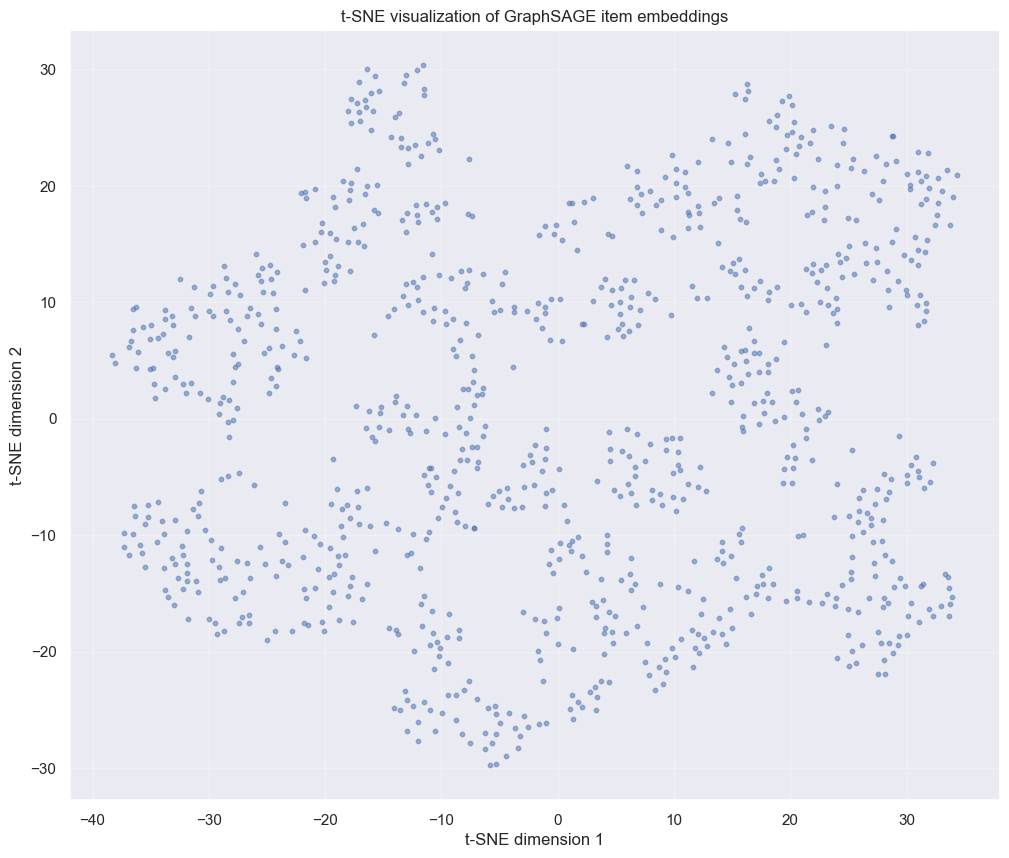

In [54]:
# Визуализация
plt.figure(figsize=(12, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, s=10)
plt.title('t-SNE visualization of GraphSAGE item embeddings')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

## Поиск похожих айтемов

In [55]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar_items(item_id, item_embeddings, id2item, items_df, n_users, k=5):
    """
    Находит k наиболее похожих айтемов
    """
    # Получаем индекс айтема
    item_internal_id = item2id[item_id]
    item_idx = item_internal_id - n_users
    
    # Вычисляем косинусное сходство
    similarities = cosine_similarity(item_embeddings[item_idx].reshape(1, -1), item_embeddings).flatten()
    
    # Топ-k похожих (исключая сам айтем)
    top_indices = np.argsort(-similarities)[1:k+1]
    
    similar_item_ids = [id2item[idx + n_users] for idx in top_indices]
    
    return similar_item_ids, similarities[top_indices]

In [60]:
# Демонстрация для случайного айтема
random_item_id = np.random.choice(list(item2id.keys()))

print(f"Исходный фильм:")
source_item = items[items.item_id == random_item_id].iloc[0]
print(f"  {source_item['title']}")
print(f"  Жанры: {source_item['genres']}")
print(f"\nПохожие фильмы:")

similar_ids, scores = find_similar_items(random_item_id, item_embeddings, id2item, items, n_users, k=5)

for i, (sim_id, score) in enumerate(zip(similar_ids, scores), 1):
    sim_item = items[items.item_id == sim_id].iloc[0]
    print(f"{i}. {sim_item['title']} (similarity: {score:.3f})")
    print(f"   Жанры: {sim_item['genres']}")

Исходный фильм:
  Время первых
  Жанры: биография, триллеры, приключения, историческое

Похожие фильмы:
1. Тоня против всех (similarity: 0.997)
   Жанры: драмы, спорт, биография, комедии
2. 28 дней (similarity: 0.995)
   Жанры: драмы, комедии
3. Срочно выйду замуж (similarity: 0.991)
   Жанры: мелодрамы, комедии
4. Крымский мост. Сделано с любовью (similarity: 0.988)
   Жанры: мелодрамы, комедии
5. Семь жизней (similarity: 0.987)
   Жанры: драмы


---

# <center> Unsupervised Pre-training для GraphSAGE </center>

Перед добавлением Knowledge Graph проведём **unsupervised pre-training** базовой модели GraphSAGE.

## Зачем нужен unsupervised pre-training?

В оригинальной статье GraphSAGE предлагается graph-based loss функция для обучения представлений без явных меток:

$$J_G(z_u) = -\log(\sigma(z_u^T z_v)) - Q \cdot \mathbb{E}_{v_n \sim P_n(v)} \log(\sigma(-z_u^T z_{v_n}))$$

где:
- $z_u$ - эмбеддинг узла $u$
- $v$ - узел, который встречается рядом с $u$ в random walk
- $v_n$ - негативные примеры (negative samples)
- $Q$ - количество негативных примеров
- $\sigma$ - сигмоид функция

**Идея**: близкие узлы в графе должны иметь похожие эмбеддинги, а далёкие - различные.

## Преимущества:

1. **Инициализация**: модель изучает структуру графа до supervised обучения
2. **Регуляризация**: pre-trained веса помогают избежать переобучения
3. **Transfer learning**: можно использовать для cold-start задач
4. **Лучшее качество**: модель быстрее сходится и показывает лучшие результаты

## Реализация:

Для обучения будем:
1. Генерировать random walks по графу для получения пар узлов (context)
2. Семплировать негативные примеры
3. Оптимизировать graph-based loss функцию

In [61]:
import random
from collections import defaultdict

def generate_random_walks(neighbors_dict, num_walks=10, walk_length=5):
    """
    Генерирует random walks для всех узлов графа.
    
    Args:
        neighbors_dict: словарь соседей для каждого узла
        num_walks: количество walks на узел
        walk_length: длина каждого walk
    
    Returns:
        walks: список walks (списков узлов)
    """
    walks = []
    nodes = list(neighbors_dict.keys())
    
    for node in nodes:
        for _ in range(num_walks):
            walk = [node]
            current = node
            
            for _ in range(walk_length - 1):
                neighbors = neighbors_dict.get(current, [])
                if len(neighbors) == 0:
                    break
                # Выбираем случайного соседа
                next_node = random.choice(neighbors)
                walk.append(next_node)
                current = next_node
            
            if len(walk) > 1:  # Добавляем только непустые walks
                walks.append(walk)
    
    return walks

def generate_pairs_from_walks(walks, window_size=2):
    """
    Генерирует пары (центральный узел, контекстный узел) из walks.
    
    Args:
        walks: список walks
        window_size: размер контекстного окна
    
    Returns:
        pairs: список пар (node, context_node)
    """
    pairs = []
    
    for walk in walks:
        for i, node in enumerate(walk):
            # Берём соседей в пределах окна
            start = max(0, i - window_size)
            end = min(len(walk), i + window_size + 1)
            
            for j in range(start, end):
                if i != j:
                    pairs.append((node, walk[j]))
    
    return pairs

print("Генерируем random walks...")
random.seed(42)
walks = generate_random_walks(neighbors, num_walks=5, walk_length=10)
print(f"Сгенерировано {len(walks)} walks")

print("\nГенерируем пары узлов...")
pairs = generate_pairs_from_walks(walks, window_size=3)
print(f"Сгенерировано {len(pairs)} пар (node, context)")

# Пример нескольких walks
print("\nПример random walks:")
for i in range(3):
    walk = walks[i]
    walk_info = []
    for node in walk[:5]:  # Показываем первые 5 узлов
        if node < n_users:
            walk_info.append(f"User_{id2user.get(node, node)}")
        else:
            item_id = id2item.get(node)
            if item_id:
                title = items[items.item_id == item_id].iloc[0]['title'][:20]
                walk_info.append(f"Item_{title}")
            else:
                walk_info.append(f"Node_{node}")
    print(f"Walk {i+1}: {' -> '.join(walk_info)}...")

Генерируем random walks...
Сгенерировано 11260 walks

Генерируем пары узлов...
Сгенерировано 540480 пар (node, context)

Пример random walks:
Walk 1: User_527655 -> Item_Вампиры средней поло -> User_527655 -> Item_Пара из будущего -> User_954033...
Walk 2: User_527655 -> Item_Сквозь снег -> User_527655 -> Item_Мастер меча -> User_239733...
Walk 3: User_527655 -> Item_Дочь волка -> User_380612 -> Item_Малефисента: Владычи -> User_718778...


In [62]:
class UnsupervisedLoss(nn.Module):
    """
    Graph-based unsupervised loss для GraphSAGE.
    
    Максимизирует близость эмбеддингов соседних узлов в графе
    и минимизирует близость с негативными примерами.
    """
    
    def __init__(self, num_negative_samples=5):
        super().__init__()
        self.Q = num_negative_samples
    
    def forward(self, node_embeddings, context_embeddings, negative_embeddings):
        """
        Args:
            node_embeddings: (batch_size, embedding_dim) - центральные узлы
            context_embeddings: (batch_size, embedding_dim) - контекстные узлы (positive)
            negative_embeddings: (batch_size, Q, embedding_dim) - негативные примеры
        
        Returns:
            loss: скалярное значение loss функции
        """
        # Positive score: z_u^T * z_v
        pos_score = torch.sum(node_embeddings * context_embeddings, dim=1)
        pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-8).mean()
        
        # Negative scores: z_u^T * z_vn для всех негативных примеров
        # node_embeddings: (batch_size, embedding_dim)
        # negative_embeddings: (batch_size, Q, embedding_dim)
        neg_scores = torch.bmm(
            negative_embeddings,  # (batch_size, Q, embedding_dim)
            node_embeddings.unsqueeze(2)  # (batch_size, embedding_dim, 1)
        ).squeeze(2)  # (batch_size, Q)
        
        neg_loss = -torch.log(torch.sigmoid(-neg_scores) + 1e-8).mean()
        
        return pos_loss + neg_loss

print("✅ UnsupervisedLoss реализован")

✅ UnsupervisedLoss реализован


In [63]:
from torch.utils.data import Dataset, DataLoader

class RandomWalkDataset(Dataset):
    """Dataset для unsupervised обучения на random walks"""
    
    def __init__(self, pairs, all_nodes, num_negative_samples=5):
        self.pairs = pairs
        self.all_nodes = all_nodes
        self.Q = num_negative_samples
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        node, context = self.pairs[idx]
        
        # Семплируем негативные примеры
        negative_nodes = np.random.choice(self.all_nodes, size=self.Q, replace=True)
        
        return node, context, negative_nodes

# Создаём dataset и dataloader
all_nodes = list(neighbors.keys())
pretrain_dataset = RandomWalkDataset(pairs, all_nodes, num_negative_samples=5)
pretrain_loader = DataLoader(pretrain_dataset, batch_size=512, shuffle=True)

print(f"Dataset size: {len(pretrain_dataset)} пар")
print(f"Batch size: 512")
print(f"Batches per epoch: {len(pretrain_loader)}")

Dataset size: 540480 пар
Batch size: 512
Batches per epoch: 1056


In [64]:
# Создаём новую модель для pre-training

# Инициализация модели
model_pretrained = GraphSAGE(
    n_nodes=n_nodes,
    embedding_dim=EMBEDDING_DIM,
    hidden_dims=HIDDEN_DIMS,
    num_neighbors_list=NUM_NEIGHBORS,
    aggregator='mean'
).to(DEVICE)



# Loss и optimizer
unsup_loss_fn = UnsupervisedLoss(num_negative_samples=5)
optimizer_pretrain = torch.optim.Adam(model_pretrained.parameters(), lr=0.001)

print("Начинаем unsupervised pre-training...\n")
print("="*80)

num_pretrain_epochs = 3
pretrain_losses = []

for epoch in range(num_pretrain_epochs):
    model_pretrained.train()
    epoch_loss = 0.0
    
    for batch_idx, (nodes, contexts, negatives) in tqdm(enumerate(pretrain_loader), total=len(pretrain_loader), desc=f"Epoch {epoch+1}/{num_pretrain_epochs}"):
        nodes = nodes.numpy()
        contexts = contexts.numpy()
        negatives = negatives.numpy()  # (batch_size, Q)
        
        optimizer_pretrain.zero_grad()
        
        # Получаем эмбеддинги
        nodes_tensor = torch.tensor(nodes, dtype=torch.long)
        contexts_tensor = torch.tensor(contexts, dtype=torch.long)
        
        node_embs = model_pretrained.forward(nodes_tensor, neighbors)
        context_embs = model_pretrained.forward(contexts_tensor, neighbors)
        
        # Получаем эмбеддинги негативных примеров
        batch_size, Q = negatives.shape
        negatives_flat = negatives.reshape(-1)  # (batch_size * Q,)
        negatives_tensor = torch.tensor(negatives_flat, dtype=torch.long)
        negative_embs_flat = model_pretrained.forward(negatives_tensor, neighbors)
        negative_embs = negative_embs_flat.reshape(batch_size, Q, -1)  # (batch_size, Q, embedding_dim)
        
        # Вычисляем loss
        loss = unsup_loss_fn(node_embs, context_embs, negative_embs)
        
        loss.backward()
        optimizer_pretrain.step()

        
        epoch_loss += loss.item()
        
        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{num_pretrain_epochs} | Batch {batch_idx+1}/{len(pretrain_loader)} | Loss: {loss.item():.4f}")
    
    avg_loss = epoch_loss / len(pretrain_loader)
    pretrain_losses.append(avg_loss)
    
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1} завершена | Average Loss: {avg_loss:.4f}")
    print(f"{'='*80}\n")

print("\n✅ Unsupervised pre-training завершён!")

Начинаем unsupervised pre-training...



Epoch 1/3:   5%|▍         | 50/1056 [00:43<14:07,  1.19it/s]

Epoch 1/3 | Batch 50/1056 | Loss: 1.3527


Epoch 1/3:   9%|▉         | 100/1056 [01:26<13:44,  1.16it/s]

Epoch 1/3 | Batch 100/1056 | Loss: 1.3254


...

Epoch 2/3 | Batch 950/1056 | Loss: 1.2108


Epoch 2/3:  95%|█████████▍| 1000/1056 [14:21<00:48,  1.16it/s]

Epoch 2/3 | Batch 1000/1056 | Loss: 1.2059


Epoch 2/3:  96%|█████████▌| 1010/1056 [14:30<00:39,  1.16it/s]


KeyboardInterrupt: 

## Fine-tuning с BPR Loss

Теперь используем pre-trained модель для fine-tuning на задаче рекомендаций с BPR loss.

**Сравним:**
- Модель обученную с нуля (from scratch)
- Модель с unsupervised pre-training + fine-tuning

In [65]:
from tqdm import tqdm

# Обучение
train_losses = []
val_recalls = []
val_ndcgs = []
avg_loss=0
optimizer = torch.optim.Adam(model_pretrained.parameters(), lr=LEARNING_RATE)
criterion = BPRLoss()

for epoch in range(NUM_EPOCHS):
    
    # Validation
    if (epoch) % 1 == 0:
        print("\nEvaluating on validation set...")
        
        # Обновляем граф с учётом val_edges_tr
        val_neighbors = defaultdict(set)
        for user, item in train_edges + val_edges_tr:
            val_neighbors[user].add(item)
            val_neighbors[item].add(user)
        val_neighbors = {k: list(v) for k, v in val_neighbors.items()}
        
        recall = recall_at_k(model_pretrained, val_edges_tr, val_edges_te, val_neighbors, n_users, n_items, k=20)
        ndcg = ndcg_at_k(model_pretrained, val_edges_tr, val_edges_te, val_neighbors, n_users, n_items, k=20)
        
        val_recalls.append(recall)
        val_ndcgs.append(ndcg)
        
        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Recall@20={recall:.4f}, NDCG@20={ndcg:.4f}")
    else:
        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}")

        model_pretrained.train()
    epoch_losses = []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in pbar:
        users, pos_items, neg_items = batch
        users = users.to(DEVICE)
        pos_items = pos_items.to(DEVICE)
        neg_items = neg_items.to(DEVICE)
        
        # Forward pass
        pos_scores = model_pretrained.predict(users, pos_items, neighbors)
        neg_scores = model_pretrained.predict(users, neg_items, neighbors)
        
        # Loss
        loss = criterion(pos_scores, neg_scores)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        pbar.set_postfix({'loss': np.mean(epoch_losses)})
    
    avg_loss = np.mean(epoch_losses)
    train_losses.append(avg_loss)


Evaluating on validation set...
Epoch 1: Loss=0.0000, Recall@20=0.1838, NDCG@20=0.0972


Epoch 1/20: 100%|██████████| 49/49 [00:16<00:00,  2.96it/s, loss=0.268]



Evaluating on validation set...
Epoch 2: Loss=0.2676, Recall@20=0.3019, NDCG@20=0.1591


Epoch 2/20: 100%|██████████| 49/49 [00:16<00:00,  2.92it/s, loss=0.245]



Evaluating on validation set...
Epoch 3: Loss=0.2452, Recall@20=0.3281, NDCG@20=0.1807


...

Epoch 18/20: 100%|██████████| 49/49 [00:16<00:00,  3.01it/s, loss=0.172]



Evaluating on validation set...
Epoch 19: Loss=0.1716, Recall@20=0.3106, NDCG@20=0.1607


Epoch 19/20: 100%|██████████| 49/49 [00:16<00:00,  2.99it/s, loss=0.17] 



Evaluating on validation set...
Epoch 20: Loss=0.1701, Recall@20=0.3014, NDCG@20=0.1608


Epoch 20/20: 100%|██████████| 49/49 [00:16<00:00,  2.97it/s, loss=0.17] 


## Построение Knowledge Graph

In [66]:
# Фильтруем items только для тех, что есть в interactions_filtered
items_filtered = items[items.item_id.isin(unique_items)].copy()

print(f"Filtered items: {len(items_filtered)}")
items_filtered.head()

Filtered items: 975


,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
45,561,film,План побега,Escape Plan,2013.0,"боевики, триллеры",США,NaN,16.0,NaN,"Микаэль Хафстрем, Микаэль Хофстрём","Сильвестр Сталлоне, Фаран Таир, Сэм Нил, Винни...",Один из самых выдающихся мировых специалистов ...,"тюрьма, заключенный, корабль, побег из тюрьмы,..."
52,13317,film,Бронсон,Bronson,2008.0,"боевики, драмы",Великобритания,NaN,16.0,NaN,Николас Виндинг Рёфн,"Том Харди, Мэтт Кинг, Джеймс Лэнс, Аманда Берт...",История жизни британского заключённого Чарльза...,"prison, isolation, biography, based on a true ..."
61,8447,film,Клуб «Кастет»,Knuckledust,2020.0,"боевики, триллеры","Великобритания, Франция",NaN,18.0,NaN,Джеймс Кермак,"Мо Данфорд, Кейт Дики, Гетин Энтони, Себастьен...",Бойцовский клуб «Кастет» – настоящая подпольна...,"2020, соединенное королевство, франция, клуб, ..."
100,3768,series,Без обид,No Offence,2015.0,"драмы, криминал, детективы, комедии",Великобритания,NaN,18.0,NaN,"Катрин Морсхэд, Миша Мэнсон-Смит, Роберт Куинн","Джоэнна Скэнлэн, Элейн Кэссиди, Уилл Меллор, П...",Работу сотрудников одного из полицейских участ...,"северная англия, полиция, темная комедия, поли..."
101,15127,series,Две судьбы,Dve sudby,2002.0,"драмы, мелодрамы, комедии",Россия,NaN,16.0,NaN,"Владимир Краснопольский, Валерий Усков","Мария Аниканова, Екатерина Семенова, Анжелика ...",В центре картины две женские истории. В начале...,NaN


In [67]:
# Парсим метаданные и создаём сущности

def parse_list_field(field_value, delimiter=', ', top_k=None):
    """Парсит строку со списком значений"""
    if pd.isna(field_value):
        return []
    values = [v.strip() for v in str(field_value).split(delimiter) if v.strip()]
    if top_k:
        return values[:top_k]
    return values

# Собираем все сущности
all_genres = set()
all_directors = set()
all_countries = set()
all_actors = set()

item_genres = {}  # item_id -> [genres]
item_directors = {}  # item_id -> [directors]
item_countries = {}  # item_id -> [countries]
item_actors = {}  # item_id -> [actors]

for _, row in items_filtered.iterrows():
    item_id = row['item_id']
    
    # Жанры
    genres = parse_list_field(row['genres'])
    all_genres.update(genres)
    item_genres[item_id] = genres
    
    # Режиссёры
    directors = parse_list_field(row['directors'])
    all_directors.update(directors)
    item_directors[item_id] = directors
    
    # Страны
    countries = parse_list_field(row['countries'])
    all_countries.update(countries)
    item_countries[item_id] = countries
    
    # Актёры (топ-3)
    actors = parse_list_field(row['actors'], top_k=3)
    all_actors.update(actors)
    item_actors[item_id] = actors

print(f"Total genres: {len(all_genres)}")
print(f"Total directors: {len(all_directors)}")
print(f"Total countries: {len(all_countries)}")
print(f"Total actors: {len(all_actors)}")
print(f"Total KG entities: {len(all_genres) + len(all_directors) + len(all_countries) + len(all_actors)}")

Total genres: 31
Total directors: 970
Total countries: 54
Total actors: 2058
Total KG entities: 3113


In [68]:
# Создаём маппинги для сущностей Knowledge Graph

# Стартовый индекс для KG сущностей (после пользователей и айтемов)
kg_start_idx = n_nodes

# Маппинги для сущностей
genre2id = {genre: idx + kg_start_idx for idx, genre in enumerate(sorted(all_genres))}
kg_start_idx += len(all_genres)

director2id = {director: idx + kg_start_idx for idx, director in enumerate(sorted(all_directors))}
kg_start_idx += len(all_directors)

country2id = {country: idx + kg_start_idx for idx, country in enumerate(sorted(all_countries))}
kg_start_idx += len(all_countries)

actor2id = {actor: idx + kg_start_idx for idx, actor in enumerate(sorted(all_actors))}
kg_start_idx += len(all_actors)

# Обратные маппинги
id2genre = {v: k for k, v in genre2id.items()}
id2director = {v: k for k, v in director2id.items()}
id2country = {v: k for k, v in country2id.items()}
id2actor = {v: k for k, v in actor2id.items()}

# Общее количество узлов в KG
n_nodes_kg = kg_start_idx

print(f"Original graph nodes: {n_nodes}")
print(f"Knowledge Graph nodes: {n_nodes_kg}")
print(f"Additional KG entity nodes: {n_nodes_kg - n_nodes}")
print(f"Breakdown:")
print(f"  Users: {n_users}")
print(f"  Items: {n_items}")
print(f"  Genres: {len(genre2id)}")
print(f"  Directors: {len(director2id)}")
print(f"  Countries: {len(country2id)}")
print(f"  Actors: {len(actor2id)}")

Original graph nodes: 2252
Knowledge Graph nodes: 5365
Additional KG entity nodes: 3113
Breakdown:
  Users: 1277
  Items: 975
  Genres: 31
  Directors: 970
  Countries: 54
  Actors: 2058


In [69]:
# Построение Knowledge Graph с дополнительными рёбрами

neighbors_kg = defaultdict(set)

# 1. Добавляем рёбра пользователь-айтем (как в базовой модели)
for user, item in train_edges:
    neighbors_kg[user].add(item)
    neighbors_kg[item].add(user)

print(f"Added {len(train_edges)} user-item edges")

# 2. Добавляем рёбра айтем-жанр
genre_edges = 0
for item_id_orig, genres in item_genres.items():
    if item_id_orig not in item2id:
        continue
    item_idx = item2id[item_id_orig]
    for genre in genres:
        if genre in genre2id:
            genre_idx = genre2id[genre]
            neighbors_kg[item_idx].add(genre_idx)
            neighbors_kg[genre_idx].add(item_idx)
            genre_edges += 1

print(f"Added {genre_edges} item-genre edges")

# 3. Добавляем рёбра айтем-режиссёр
director_edges = 0
for item_id_orig, directors in item_directors.items():
    if item_id_orig not in item2id:
        continue
    item_idx = item2id[item_id_orig]
    for director in directors:
        if director in director2id:
            director_idx = director2id[director]
            neighbors_kg[item_idx].add(director_idx)
            neighbors_kg[director_idx].add(item_idx)
            director_edges += 1

print(f"Added {director_edges} item-director edges")

# 4. Добавляем рёбра айтем-страна
country_edges = 0
for item_id_orig, countries in item_countries.items():
    if item_id_orig not in item2id:
        continue
    item_idx = item2id[item_id_orig]
    for country in countries:
        if country in country2id:
            country_idx = country2id[country]
            neighbors_kg[item_idx].add(country_idx)
            neighbors_kg[country_idx].add(item_idx)
            country_edges += 1

print(f"Added {country_edges} item-country edges")

# 5. Добавляем рёбра айтем-актёр
actor_edges = 0
for item_id_orig, actors in item_actors.items():
    if item_id_orig not in item2id:
        continue
    item_idx = item2id[item_id_orig]
    for actor in actors:
        if actor in actor2id:
            actor_idx = actor2id[actor]
            neighbors_kg[item_idx].add(actor_idx)
            neighbors_kg[actor_idx].add(item_idx)
            actor_edges += 1

print(f"Added {actor_edges} item-actor edges")

print("" + "="*80)
print("Добавляем прямые связи: ПОЛЬЗОВАТЕЛЬ -> KG ENTITIES")
print("="*80 + "")

# 6. НОВОЕ: Добавляем рёбра пользователь -> KG entities
# На основе истории просмотров пользователя создаём связи с жанрами, режиссёрами и т.д.

user_genre_edges = 0
user_director_edges = 0
user_country_edges = 0
user_actor_edges = 0

# Для каждого пользователя собираем его предпочтения
for user_idx, item_idx in train_edges:
    # Получаем original item_id
    if item_idx not in id2item:
        continue
    
    item_id_orig = id2item[item_idx]
    
    # Добавляем связи user -> genres
    if item_id_orig in item_genres:
        for genre in item_genres[item_id_orig]:
            if genre in genre2id:
                genre_idx = genre2id[genre]
                if genre_idx not in neighbors_kg[user_idx]:  # Избегаем дубликатов
                    neighbors_kg[user_idx].add(genre_idx)
                    neighbors_kg[genre_idx].add(user_idx)
                    user_genre_edges += 1
    
    # Добавляем связи user -> directors
    if item_id_orig in item_directors:
        for director in item_directors[item_id_orig]:
            if director in director2id:
                director_idx = director2id[director]
                if director_idx not in neighbors_kg[user_idx]:
                    neighbors_kg[user_idx].add(director_idx)
                    neighbors_kg[director_idx].add(user_idx)
                    user_director_edges += 1
    
    # Добавляем связи user -> countries
    if item_id_orig in item_countries:
        for country in item_countries[item_id_orig]:
            if country in country2id:
                country_idx = country2id[country]
                if country_idx not in neighbors_kg[user_idx]:
                    neighbors_kg[user_idx].add(country_idx)
                    neighbors_kg[country_idx].add(user_idx)
                    user_country_edges += 1
    
    # Добавляем связи user -> actors
    if item_id_orig in item_actors:
        for actor in item_actors[item_id_orig]:
            if actor in actor2id:
                actor_idx = actor2id[actor]
                if actor_idx not in neighbors_kg[user_idx]:
                    neighbors_kg[user_idx].add(actor_idx)
                    neighbors_kg[actor_idx].add(user_idx)
                    user_actor_edges += 1

print(f"Added {user_genre_edges} user-genre edges")
print(f"Added {user_director_edges} user-director edges")
print(f"Added {user_country_edges} user-country edges")
print(f"Added {user_actor_edges} user-actor edges")

# Преобразуем в списки
neighbors_kg = {k: list(v) for k, v in neighbors_kg.items()}

print(f"Knowledge Graph constructed with {len(neighbors_kg)} nodes")
print(f"Total edges: {sum(len(v) for v in neighbors_kg.values()) // 2}")
print(f"Average degree: {np.mean([len(v) for v in neighbors_kg.values()]):.2f}")

# Статистика по типам узлов
user_nodes = [n for n in neighbors_kg.keys() if n < n_users]
item_nodes = [n for n in neighbors_kg.keys() if n_users <= n < n_nodes]
kg_entity_nodes = [n for n in neighbors_kg.keys() if n >= n_nodes]

print(f"Node statistics:")
print(f"  User nodes: {len(user_nodes)}")
print(f"  Item nodes: {len(item_nodes)}")
print(f"  KG entity nodes: {len(kg_entity_nodes)}")

if len(user_nodes) > 0:
    user_avg_degree = np.mean([len(neighbors_kg[u]) for u in user_nodes])
    print(f"  Average user degree: {user_avg_degree:.2f}")

if len(item_nodes) > 0:
    item_avg_degree = np.mean([len(neighbors_kg[i]) for i in item_nodes])
    print(f"  Average item degree: {item_avg_degree:.2f}")

if len(kg_entity_nodes) > 0:
    kg_avg_degree = np.mean([len(neighbors_kg[k]) for k in kg_entity_nodes])
    print(f"  Average KG entity degree: {kg_avg_degree:.2f}")

Added 12442 user-item edges
Added 2677 item-genre edges
Added 1190 item-director edges
Added 1393 item-country edges
Added 2861 item-actor edges
Добавляем прямые связи: ПОЛЬЗОВАТЕЛЬ -> KG ENTITIES
Added 10461 user-genre edges
Added 14406 user-director edges
Added 6349 user-country edges
Added 35094 user-actor edges
Knowledge Graph constructed with 5111 nodes
Total edges: 86873
Average degree: 33.99
Node statistics:
  User nodes: 1023
  Item nodes: 975
  KG entity nodes: 3113
  Average user degree: 76.98
  Average item degree: 21.09
  Average KG entity degree: 23.91


## Обучение GraphSAGE с Knowledge Graph

In [70]:
# Инициализация модели с KG
model_kg = GraphSAGE(
    n_nodes=n_nodes_kg,  # Используем расширенное количество узлов
    embedding_dim=EMBEDDING_DIM,
    hidden_dims=HIDDEN_DIMS,
    num_neighbors_list=NUM_NEIGHBORS,
    aggregator='mean'
).to(DEVICE)

optimizer_kg = torch.optim.Adam(model_kg.parameters(), lr=LEARNING_RATE)
criterion_kg = BPRLoss()

print(f"Model with KG parameters: {sum(p.numel() for p in model_kg.parameters())}")

Model with KG parameters: 376320


In [71]:
# Обучение модели с KG
train_losses_kg = []
val_recalls_kg = []
val_ndcgs_kg = []
avg_loss_kg = 0

for epoch in range(NUM_EPOCHS):
    
    # Validation
    if (epoch) % 1 == 0:
        print("Evaluating on validation set...")
        
        # Обновляем граф с учётом val_edges_tr
        val_neighbors_kg = defaultdict(set)
        
        # User-item edges
        for user, item in train_edges + val_edges_tr:
            val_neighbors_kg[user].add(item)
            val_neighbors_kg[item].add(user)
        
        # Item-KG entity edges (копируем из основного графа)
        for node, neighs in neighbors_kg.items():
            if node >= n_nodes:  # KG entity node
                val_neighbors_kg[node].update(neighs)
            elif node >= n_users:  # Item node
                for neigh in neighs:
                    if neigh >= n_nodes:  # KG entity
                        val_neighbors_kg[node].add(neigh)
                        val_neighbors_kg[neigh].add(node)
        
        val_neighbors_kg = {k: list(v) for k, v in val_neighbors_kg.items()}
        
        recall_kg = recall_at_k(model_kg, val_edges_tr, val_edges_te, val_neighbors_kg, n_users, n_items, k=20)
        ndcg_kg = ndcg_at_k(model_kg, val_edges_tr, val_edges_te, val_neighbors_kg, n_users, n_items, k=20)
        
        val_recalls_kg.append(recall_kg)
        val_ndcgs_kg.append(ndcg_kg)
        
        print(f"Epoch {epoch+1}: Loss={avg_loss_kg:.4f}, Recall@20={recall_kg:.4f}, NDCG@20={ndcg_kg:.4f}")
    
    model_kg.train()
    epoch_losses = []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} (KG)")
    for batch in pbar:
        users, pos_items, neg_items = batch
        users = users.to(DEVICE)
        pos_items = pos_items.to(DEVICE)
        neg_items = neg_items.to(DEVICE)
        
        # Forward pass
        pos_scores = model_kg.predict(users, pos_items, neighbors_kg)
        neg_scores = model_kg.predict(users, neg_items, neighbors_kg)
        
        # Loss
        loss = criterion_kg(pos_scores, neg_scores)
        
        # Backward pass
        optimizer_kg.zero_grad()
        loss.backward()
        optimizer_kg.step()
        
        epoch_losses.append(loss.item())
        pbar.set_postfix({'loss': np.mean(epoch_losses)})
    
    avg_loss_kg = np.mean(epoch_losses)
    train_losses_kg.append(avg_loss_kg)

Evaluating on validation set...
Epoch 1: Loss=0.0000, Recall@20=0.0050, NDCG@20=0.0031


Epoch 1/20 (KG): 100%|██████████| 49/49 [00:30<00:00,  1.60it/s, loss=0.588]


Evaluating on validation set...
Epoch 2: Loss=0.5883, Recall@20=0.2921, NDCG@20=0.1493


Epoch 2/20 (KG): 100%|██████████| 49/49 [00:29<00:00,  1.64it/s, loss=0.499]


Evaluating on validation set...
Epoch 3: Loss=0.4990, Recall@20=0.2864, NDCG@20=0.1618


...

Epoch 18/20 (KG): 100%|██████████| 49/49 [00:29<00:00,  1.66it/s, loss=0.362]


Evaluating on validation set...
Epoch 19: Loss=0.3621, Recall@20=0.2972, NDCG@20=0.1377


Epoch 19/20 (KG): 100%|██████████| 49/49 [00:29<00:00,  1.66it/s, loss=0.359]


Evaluating on validation set...
Epoch 20: Loss=0.3587, Recall@20=0.2862, NDCG@20=0.1455


Epoch 20/20 (KG): 100%|██████████| 49/49 [00:29<00:00,  1.65it/s, loss=0.362]


## Анализ влияния Knowledge Graph

In [72]:
# Анализируем, как KG влияет на рекомендации

def analyze_kg_impact(user_id, model_base, model_kg, neighbors_base, neighbors_kg, 
                      id2item, items_df, n_users, n_items, k=10):
    """
    Сравнивает рекомендации базовой модели и модели с KG для конкретного пользователя
    """
    print(f"{'='*80}")
    print(f"User ID: {id2user[user_id]} (internal: {user_id})")
    print(f"{'='*80}")
    
    # История
    if user_id in neighbors_base:
        seen_items = [item for item in neighbors_base[user_id] if item >= n_users]
        seen_item_ids = [id2item[item] for item in seen_items]
        
        history = items_df[items_df.item_id.isin(seen_item_ids)]
        print("История просмотров:")
        print(history[['title', 'genres']].head(5).to_string(index=False))
        if len(history) > 5:
            print(f"... и ещё {len(history) - 5} фильмов")
    
    # Рекомендации базовой модели
    print(f"{'='*80}")
    print(f"Топ-{k} рекомендаций (Baseline):")
    print(f"{'='*80}")
    
    rec_items_base = get_user_recommendations(model_base, user_id, neighbors_base, n_users, n_items, k)
    rec_item_ids_base = [id2item[item] for item in rec_items_base]
    recommendations_base = items_df[items_df.item_id.isin(rec_item_ids_base)]
    print(recommendations_base[['title', 'genres']].to_string(index=False))
    
    # Рекомендации модели с KG
    print(f"{'='*80}")
    print(f"Топ-{k} рекомендаций (With KG):")
    print(f"{'='*80}")
    
    rec_items_kg = get_user_recommendations(model_kg, user_id, neighbors_kg, n_users, n_items, k)
    rec_item_ids_kg = [id2item[item] for item in rec_items_kg]
    recommendations_kg = items_df[items_df.item_id.isin(rec_item_ids_kg)]
    print(recommendations_kg[['title', 'genres']].to_string(index=False))
    
    # Анализ различий
    overlap = len(set(rec_item_ids_base) & set(rec_item_ids_kg))
    print(f"{'='*80}")
    print(f"Overlap: {overlap}/{k} рекомендаций совпадают")
    print(f"Различия: {k - overlap}/{k} рекомендаций отличаются")
    print(f"{'='*80}")

In [77]:
# Построение графа для KG модели (для демонстрации)
demo_neighbors_kg = defaultdict(set)

# User-item edges
for user, item in train_edges:
    demo_neighbors_kg[user].add(item)
    demo_neighbors_kg[item].add(user)

# Item-KG entity edges
for node, neighs in neighbors_kg.items():
    if node >= n_nodes:  # KG entity node
        demo_neighbors_kg[node].update(neighs)
    elif node >= n_users:  # Item node
        for neigh in neighs:
            if neigh >= n_nodes:  # KG entity
                demo_neighbors_kg[node].add(neigh)
                demo_neighbors_kg[neigh].add(node)

demo_neighbors_kg = {k: list(v) for k, v in demo_neighbors_kg.items()}

# Демонстрация для случайного пользователя
random_user = np.random.choice(list(user2id.values()))
analyze_kg_impact(
    random_user,
    model,
    model_kg,
    neighbors,  # Базовая модель использует простой граф
    demo_neighbors_kg,  # KG модель использует расширенный граф
    id2item,
    items,
    n_users,
    n_items,
    k=10
)

User ID: 359451 (internal: 521)
История просмотров:
                title                                    genres
                Афера                                   комедии
        Крёстная мама                            драмы, комедии
      Малыш на драйве         боевики, драмы, триллеры, комедии
Человек-муравей и Оса боевики, фантастика, приключения, комедии
         Фемида видит                 драмы, детективы, комедии
... и ещё 1 фильмов
Топ-10 рекомендаций (Baseline):
                       title                       genres
             Клиника счастья             драмы, мелодрамы
                 Хрустальный          триллеры, детективы
           Гнев человеческий            боевики, триллеры
                    Девятаев  драмы, военные, приключения
                       Немцы                        драмы
                    Пальмира                        драмы
Прабабушка легкого поведения                      комедии
                  Подслушано              драмы,

## Визуализация Knowledge Graph embeddings

In [78]:
# Получаем embeddings для айтемов из модели с KG
model_kg.eval()
with torch.no_grad():
    all_item_indices_kg = torch.arange(n_users, n_users + n_items)
    item_embeddings_kg = model_kg.forward(all_item_indices_kg, neighbors_kg).cpu().numpy()

print(f"Item embeddings (KG) shape: {item_embeddings_kg.shape}")

# t-SNE визуализация
tsne_kg = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d_kg = tsne_kg.fit_transform(item_embeddings_kg[sample_indices])

print(f"t-SNE embeddings (KG) shape: {embeddings_2d_kg.shape}")

Item embeddings (KG) shape: (975, 64)
t-SNE embeddings (KG) shape: (975, 2)


## Интерактивная визуализация Knowledge Graph

Создадим интерактивную визуализацию подграфа Knowledge Graph с выученными близостями между узлами.

In [79]:
# Устанавливаем необходимые библиотеки (если нужно)
# !pip install plotly networkx

In [80]:
import networkx as nx
import plotly.graph_objects as go
from sklearn.metrics.pairwise import cosine_similarity

def build_kg_subgraph(item_id, neighbors_kg, item2id, genre2id, director2id, country2id, actor2id,
                       n_users, n_nodes, max_neighbors=5):
    """
    Строит подграф вокруг заданного айтема, включая его KG-связи
    """
    G = nx.Graph()
    
    if item_id not in item2id:
        return G
    
    item_idx = item2id[item_id]
    
    # Добавляем центральный айтем
    G.add_node(item_idx, node_type='item', label=f'Item {item_id}')
    
    # Получаем соседей айтема
    if item_idx in neighbors_kg:
        neighs = neighbors_kg[item_idx]
        
        # Разделяем соседей по типам
        user_neighs = [n for n in neighs if n < n_users]
        item_neighs = [n for n in neighs if n_users <= n < n_nodes]
        kg_entity_neighs = [n for n in neighs if n >= n_nodes]
        
        # Добавляем KG entities (жанры, режиссёры, страны, актёры)
        for entity_idx in kg_entity_neighs:
            # Определяем тип entity
            if entity_idx in id2genre:
                entity_type = 'genre'
                entity_label = id2genre[entity_idx]
            elif entity_idx in id2director:
                entity_type = 'director'
                entity_label = id2director[entity_idx]
            elif entity_idx in id2country:
                entity_type = 'country'
                entity_label = id2country[entity_idx]
            elif entity_idx in id2actor:
                entity_type = 'actor'
                entity_label = id2actor[entity_idx]
            else:
                continue
            
            G.add_node(entity_idx, node_type=entity_type, label=entity_label)
            G.add_edge(item_idx, entity_idx)
            
            # Добавляем другие айтемы, связанные с этой entity (ограничиваем количество)
            if entity_idx in neighbors_kg:
                connected_items = [n for n in neighbors_kg[entity_idx] 
                                  if n_users <= n < n_nodes and n != item_idx][:max_neighbors]
                
                for connected_item in connected_items:
                    if connected_item in id2item:
                        G.add_node(connected_item, node_type='item', 
                                  label=f'Item {id2item[connected_item]}')
                        G.add_edge(entity_idx, connected_item)
    
    return G

print("Функция построения подграфа готова!")

Функция построения подграфа готова!


In [81]:
def visualize_kg_interactive(G, model_kg, neighbors_kg, items_df, id2item, n_users, title="Knowledge Graph"):
    """
    Создаёт интерактивную визуализацию графа с использованием Plotly
    """
    if len(G.nodes()) == 0:
        print("Граф пуст!")
        return
    
    # Вычисляем позиции узлов с помощью spring layout
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Получаем embeddings для узлов (только для айтемов)
    node_embeddings = {}
    item_nodes = [n for n in G.nodes() if G.nodes[n]['node_type'] == 'item']
    
    if len(item_nodes) > 1:
        with torch.no_grad():
            model_kg.eval()
            item_indices = torch.tensor(item_nodes)
            embeddings = model_kg.forward(item_indices, neighbors_kg).cpu().numpy()
            
            for node, emb in zip(item_nodes, embeddings):
                node_embeddings[node] = emb
    
    # Создаём traces для рёбер
    edge_trace = go.Scatter(
        x=[],
        y=[],
        line=dict(width=0.5, color='#888'),
        hoverinfo='none',
        mode='lines')
    
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_trace['x'] += tuple([x0, x1, None])
        edge_trace['y'] += tuple([y0, y1, None])
    
    # Создаём traces для узлов по типам
    node_traces = {}
    node_types = {
        'item': {'color': '#FF6B6B', 'size': 15, 'symbol': 'circle'},
        'genre': {'color': '#4ECDC4', 'size': 12, 'symbol': 'square'},
        'director': {'color': '#45B7D1', 'size': 12, 'symbol': 'diamond'},
        'country': {'color': '#FFA07A', 'size': 12, 'symbol': 'star'},
        'actor': {'color': '#98D8C8', 'size': 10, 'symbol': 'triangle-up'}
    }
    
    for node_type, style in node_types.items():
        node_trace = go.Scatter(
            x=[],
            y=[],
            text=[],
            hovertext=[],
            mode='markers+text',
            hoverinfo='text',
            name=node_type.capitalize(),
            marker=dict(
                color=style['color'],
                size=style['size'],
                symbol=style['symbol'],
                line=dict(width=2, color='white')
            ),
            textposition="top center",
            textfont=dict(size=8)
        )
        node_traces[node_type] = node_trace
    
    # Заполняем данные узлов
    for node in G.nodes():
        x, y = pos[node]
        node_type = G.nodes[node]['node_type']
        label = G.nodes[node]['label']
        
        # Для айтемов добавляем информацию о фильме
        if node_type == 'item' and node in id2item:
            item_id = id2item[node]
            item_info = items_df[items_df.item_id == item_id]
            if not item_info.empty:
                item_row = item_info.iloc[0]
                title = item_row['title']
                genres = item_row['genres']
                
                hover_text = f"<b>{title}</b><br>Жанры: {genres}<br>ID: {item_id}"
                display_label = title[:20] + '...' if len(str(title)) > 20 else title
            else:
                hover_text = label
                display_label = label
        else:
            hover_text = f"<b>{node_type.capitalize()}</b><br>{label}"
            display_label = label[:15] + '...' if len(str(label)) > 15 else label
        
        node_traces[node_type]['x'] += tuple([x])
        node_traces[node_type]['y'] += tuple([y])
        node_traces[node_type]['text'] += tuple([display_label])
        node_traces[node_type]['hovertext'] += tuple([hover_text])
            
    # Создаём figure
    fig = go.Figure(
        data=[edge_trace] + list(node_traces.values()),
        layout=go.Layout(
            title=title,
            #titlefont_size=16,
            showlegend=True,
            hovermode='closest',
            margin=dict(b=20, l=5, r=5, t=40),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            plot_bgcolor='white',
            height=800,
            legend=dict(
                yanchor="top",
                y=0.99,
                xanchor="left",
                x=0.01
            )
        )
    )
    
    # Добавляем информацию о сходстве для айтемов
    if len(node_embeddings) > 1:
        # Вычисляем матрицу сходства
        emb_list = list(node_embeddings.values())
        node_list = list(node_embeddings.keys())
        
        similarities = cosine_similarity(emb_list)
        
        # Добавляем аннотации для наиболее похожих пар
        annotations = []
        for i in range(len(node_list)):
            for j in range(i+1, len(node_list)):
                sim = similarities[i][j]
                if sim > 0.9:  # Показываем только высокое сходство
                    x0, y0 = pos[node_list[i]]
                    x1, y1 = pos[node_list[j]]
                    mid_x, mid_y = (x0 + x1) / 2, (y0 + y1) / 2
                    
                    annotations.append(
                        dict(
                            x=mid_x,
                            y=mid_y,
                            text=f"{sim:.2f}",
                            showarrow=False,
                            font=dict(size=8, color="red"),
                            bgcolor="rgba(255, 255, 255, 0.8)",
                            bordercolor="red",
                            borderwidth=1
                        )
                    )
        
        fig.update_layout(annotations=annotations)
    
    fig.show()
    
    return fig

print("Функция визуализации готова!")

Функция визуализации готова!


In [82]:
# Выбираем случайный популярный фильм для визуализации
popular_items = interactions_filtered.item_id.value_counts().head(20).index.tolist()
random_item_for_vis = np.random.choice(popular_items)

print(f"Визуализация Knowledge Graph для фильма: {random_item_for_vis}")

item_info = items[items.item_id == random_item_for_vis].iloc[0]
print(f"Название: {item_info['title']}")
print(f"Жанры: {item_info['genres']}")
print(f"Режиссёр: {item_info['directors']}")
print(f"Страна: {item_info['countries']}")

# Строим подграф
G = build_kg_subgraph(
    random_item_for_vis,
    neighbors_kg,
    item2id,
    genre2id,
    director2id,
    country2id,
    actor2id,
    n_users,
    n_nodes,
    max_neighbors=3
)

print(f"Подграф содержит {G.number_of_nodes()} узлов и {G.number_of_edges()} рёбер")

# Визуализируем
fig = visualize_kg_interactive(
    G,
    model_kg,
    neighbors_kg,
    items,
    id2item,
    n_users,
    title=f"Knowledge Graph: {item_info['title']}"
)

Визуализация Knowledge Graph для фильма: 2657
Название: Подслушано
Жанры: драмы, триллеры
Режиссёр: Илья Куликов
Страна: Россия
Подграф содержит 17 узлов и 16 рёбер


### Сравнение двух фильмов через Knowledge Graph

In [83]:
def build_comparison_subgraph(item_id1, item_id2, neighbors_kg, item2id, genre2id, 
                               director2id, country2id, actor2id, n_users, n_nodes):
    """
    Строит подграф, показывающий связи между двумя айтемами через KG
    """
    G = nx.Graph()
    
    if item_id1 not in item2id or item_id2 not in item2id:
        return G
    
    item_idx1 = item2id[item_id1]
    item_idx2 = item2id[item_id2]
    
    # Добавляем оба айтема
    G.add_node(item_idx1, node_type='item', label=f'Item {item_id1}', is_target=True)
    G.add_node(item_idx2, node_type='item', label=f'Item {item_id2}', is_target=True)
    
    # Получаем общих соседей (KG entities)
    neighs1 = set(neighbors_kg.get(item_idx1, []))
    neighs2 = set(neighbors_kg.get(item_idx2, []))
    
    common_entities = (neighs1 & neighs2) - set(range(n_users))  # Исключаем пользователей
    
    # Добавляем общие KG entities
    for entity_idx in common_entities:
        if entity_idx in id2genre:
            entity_type = 'genre'
            entity_label = id2genre[entity_idx]
        elif entity_idx in id2director:
            entity_type = 'director'
            entity_label = id2director[entity_idx]
        elif entity_idx in id2country:
            entity_type = 'country'
            entity_label = id2country[entity_idx]
        elif entity_idx in id2actor:
            entity_type = 'actor'
            entity_label = id2actor[entity_idx]
        else:
            continue
        
        G.add_node(entity_idx, node_type=entity_type, label=entity_label, is_common=True)
        G.add_edge(item_idx1, entity_idx)
        G.add_edge(item_idx2, entity_idx)
    
    # Добавляем уникальные entities для каждого айтема (ограничиваем)
    unique_entities1 = list((neighs1 - neighs2) - set(range(n_users)))[:3]
    unique_entities2 = list((neighs2 - neighs1) - set(range(n_users)))[:3]
    
    for entity_idx in unique_entities1 + unique_entities2:
        if entity_idx >= n_nodes:
            if entity_idx in id2genre:
                entity_type = 'genre'
                entity_label = id2genre[entity_idx]
            elif entity_idx in id2director:
                entity_type = 'director'
                entity_label = id2director[entity_idx]
            elif entity_idx in id2country:
                entity_type = 'country'
                entity_label = id2country[entity_idx]
            elif entity_idx in id2actor:
                entity_type = 'actor'
                entity_label = id2actor[entity_idx]
            else:
                continue
            
            G.add_node(entity_idx, node_type=entity_type, label=entity_label, is_common=False)
            
            if entity_idx in unique_entities1:
                G.add_edge(item_idx1, entity_idx)
            else:
                G.add_edge(item_idx2, entity_idx)
    
    return G

print("Функция сравнения готова!")

Функция сравнения готова!


In [87]:
# Выбираем два похожих фильма для сравнения
sample_item = np.random.choice(list(item2id.keys()))

# Получаем embedding
with torch.no_grad():
    sample_emb = model_kg.forward(torch.tensor([item2id[sample_item]]), neighbors_kg).cpu().numpy()
    all_item_embs_kg = model_kg.forward(torch.arange(n_users, n_users + n_items), neighbors_kg).cpu().numpy()

# Находим похожий фильм
sims = cosine_similarity(sample_emb, all_item_embs_kg).flatten()
top_similar_idx = np.argsort(-sims)[1]  # Берём второй (первый - сам фильм)
similar_item = id2item[n_users + top_similar_idx]

print(f"Сравниваем два фильма:")
print(f"Фильм 1: {items[items.item_id == sample_item].iloc[0]['title']}")
print(f"  Жанры: {items[items.item_id == sample_item].iloc[0]['genres']}")

print(f"Фильм 2: {items[items.item_id == similar_item].iloc[0]['title']}")
print(f"  Жанры: {items[items.item_id == similar_item].iloc[0]['genres']}")

print(f"Cosine similarity: {sims[top_similar_idx]:.4f}")

# Строим граф сравнения
G_comp = build_comparison_subgraph(
    sample_item,
    similar_item,
    neighbors_kg,
    item2id,
    genre2id,
    director2id,
    country2id,
    actor2id,
    n_users,
    n_nodes
)

print(f"Граф содержит {G_comp.number_of_nodes()} узлов и {G_comp.number_of_edges()} рёбер")

if G_comp.number_of_nodes() > 0:
    fig_comp = visualize_kg_interactive(
        G_comp,
        model_kg,
        neighbors_kg,
        items,
        id2item,
        n_users,
        title="Сравнение двух фильмов через Knowledge Graph"
    )
else:
    print("Нет общих KG entities между фильмами!")

Сравниваем два фильма:
Фильм 1: Царство
  Жанры: боевики, драмы, историческое, военные
Фильм 2: Сталинград
  Жанры: боевики, драмы, военные
Cosine similarity: 0.9973
Граф содержит 11 узлов и 12 рёбер


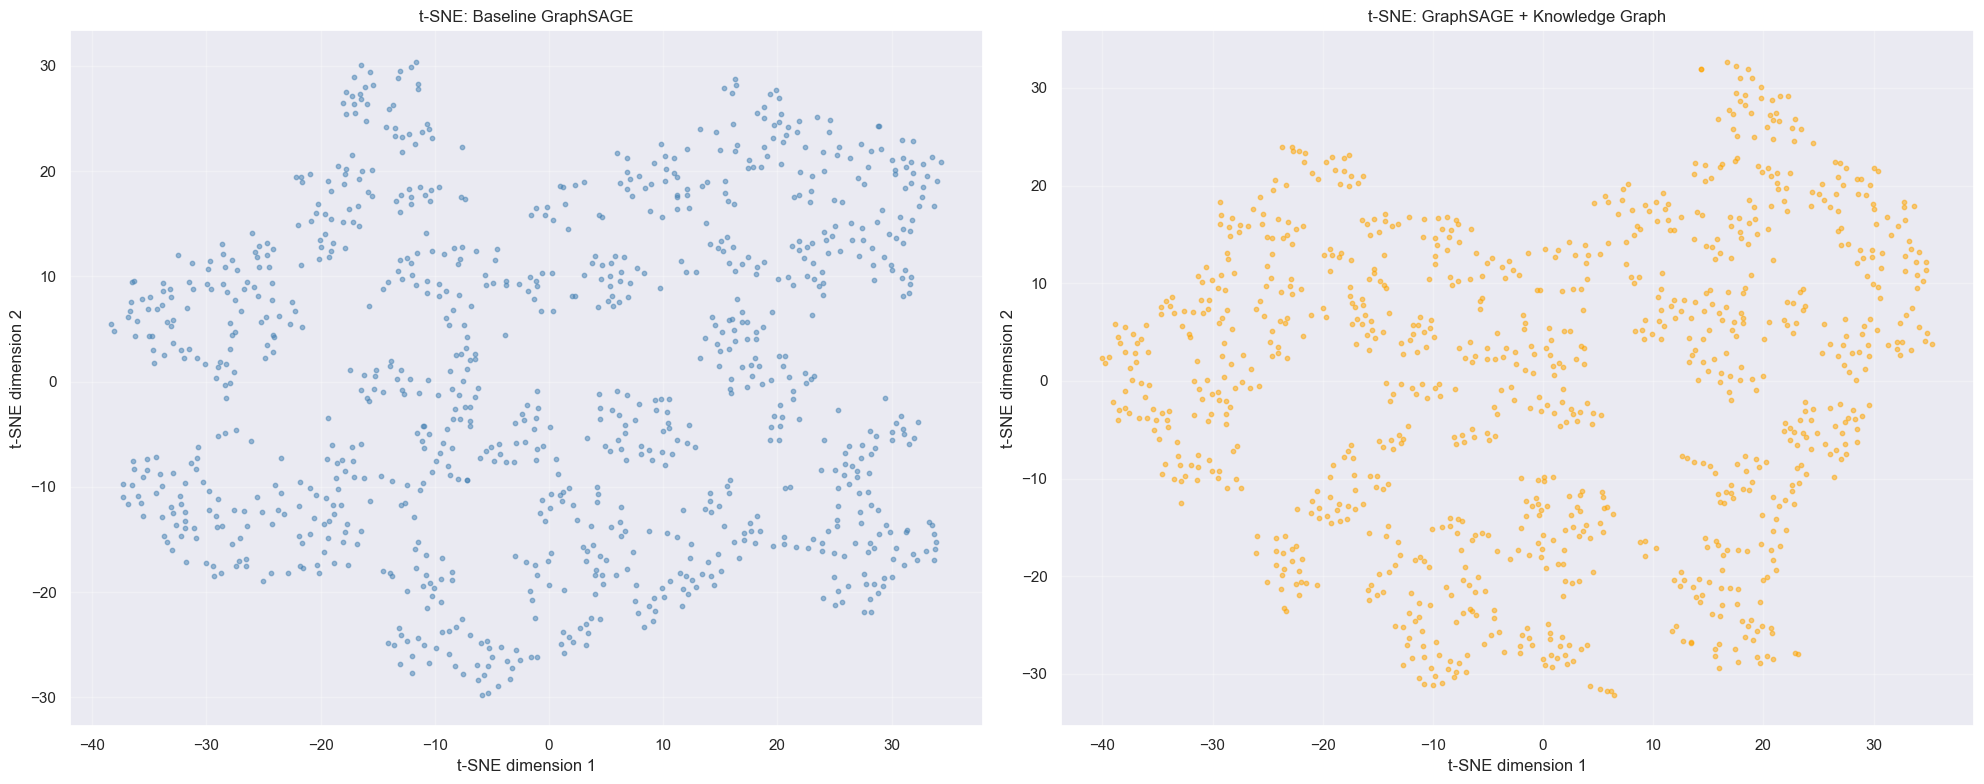

In [88]:
# Сравнение t-SNE визуализаций
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Baseline
axes[0].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5, s=10, c='steelblue')
axes[0].set_title('t-SNE: Baseline GraphSAGE')
axes[0].set_xlabel('t-SNE dimension 1')
axes[0].set_ylabel('t-SNE dimension 2')
axes[0].grid(True, alpha=0.3)

# With KG
axes[1].scatter(embeddings_2d_kg[:, 0], embeddings_2d_kg[:, 1], alpha=0.5, s=10, c='orange')
axes[1].set_title('t-SNE: GraphSAGE + Knowledge Graph')
axes[1].set_xlabel('t-SNE dimension 1')
axes[1].set_ylabel('t-SNE dimension 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Визуализация профиля пользователя через Knowledge Graph

Теперь пользователи напрямую связаны с жанрами, режиссёрами, странами и актёрами на основе их истории просмотров. Это позволяет модели лучше понимать предпочтения пользователей.

In [89]:
def build_user_kg_subgraph(user_idx, neighbors_kg, id2item, id2genre, id2director, 
                           id2country, id2actor, n_users, n_nodes, max_items=5, max_entities=5):
    """
    Строит подграф вокруг пользователя, показывая его связи с айтемами и KG entities
    """
    G = nx.Graph()
    
    if user_idx not in neighbors_kg:
        return G
    
    # Добавляем пользователя
    G.add_node(user_idx, node_type='user', label=f'User {user_idx}', is_center=True)
    
    neighs = neighbors_kg[user_idx]
    
    # Разделяем соседей по типам
    item_neighs = [n for n in neighs if n_users <= n < n_nodes]
    kg_entity_neighs = [n for n in neighs if n >= n_nodes]
    
    # Добавляем айтемы (ограничиваем количество)
    for item_idx in item_neighs[:max_items]:
        if item_idx in id2item:
            G.add_node(item_idx, node_type='item', label=f'Item {id2item[item_idx]}')
            G.add_edge(user_idx, item_idx, edge_type='watched')
    
    # Группируем KG entities по типам
    genres = []
    directors = []
    countries = []
    actors = []
    
    for entity_idx in kg_entity_neighs:
        if entity_idx in id2genre:
            genres.append((entity_idx, id2genre[entity_idx]))
        elif entity_idx in id2director:
            directors.append((entity_idx, id2director[entity_idx]))
        elif entity_idx in id2country:
            countries.append((entity_idx, id2country[entity_idx]))
        elif entity_idx in id2actor:
            actors.append((entity_idx, id2actor[entity_idx]))
    
    # Добавляем топ KG entities каждого типа
    for entity_idx, label in genres[:max_entities]:
        G.add_node(entity_idx, node_type='genre', label=label)
        G.add_edge(user_idx, entity_idx, edge_type='prefers')
    
    for entity_idx, label in directors[:max_entities]:
        G.add_node(entity_idx, node_type='director', label=label)
        G.add_edge(user_idx, entity_idx, edge_type='prefers')
    
    for entity_idx, label in countries[:max_entities]:
        G.add_node(entity_idx, node_type='country', label=label)
        G.add_edge(user_idx, entity_idx, edge_type='prefers')
    
    for entity_idx, label in actors[:max_entities]:
        G.add_node(entity_idx, node_type='actor', label=label)
        G.add_edge(user_idx, entity_idx, edge_type='prefers')
    
    return G

print("Функция построения user subgraph готова!")

Функция построения user subgraph готова!


In [90]:
def visualize_user_kg_profile(G, items_df, id2item, id2user, n_users, title="User Knowledge Graph Profile"):
    """
    Визуализирует профиль пользователя в KG с разными цветами для разных типов связей
    """
    if len(G.nodes()) == 0:
        print("Граф пуст!")
        return
    
    # Layout с центральным пользователем
    # Находим центрального пользователя
    center_user = [n for n in G.nodes() if G.nodes[n].get('is_center', False)]
    
    if center_user:
        # Создаём layout с пользователем в центре
        pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
        # Помещаем пользователя строго в центр
        pos[center_user[0]] = np.array([0.0, 0.0])
    else:
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Создаём traces для рёбер разных типов
    edge_traces = {}
    
    for edge in G.edges(data=True):
        edge_type = edge[2].get('edge_type', 'default')
        
        if edge_type not in edge_traces:
            color = '#FF6B6B' if edge_type == 'watched' else '#95E1D3'
            edge_traces[edge_type] = go.Scatter(
                x=[],
                y=[],
                line=dict(width=2 if edge_type == 'watched' else 1.5, color=color),
                hoverinfo='none',
                mode='lines',
                name=edge_type,
                showlegend=True
            )
        
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_traces[edge_type]['x'] += tuple([x0, x1, None])
        edge_traces[edge_type]['y'] += tuple([y0, y1, None])
    
    # Создаём traces для узлов
    node_traces = {}
    node_types = {
        'user': {'color': '#8B5CF6', 'size': 25, 'symbol': 'star'},  # Фиолетовая звезда
        'item': {'color': '#FF6B6B', 'size': 15, 'symbol': 'circle'},
        'genre': {'color': '#4ECDC4', 'size': 12, 'symbol': 'square'},
        'director': {'color': '#45B7D1', 'size': 12, 'symbol': 'diamond'},
        'country': {'color': '#FFA07A', 'size': 12, 'symbol': 'hexagon'},
        'actor': {'color': '#98D8C8', 'size': 10, 'symbol': 'triangle-up'}
    }
    
    for node_type, style in node_types.items():
        node_trace = go.Scatter(
            x=[],
            y=[],
            text=[],
            hovertext=[],
            mode='markers+text',
            hoverinfo='text',
            name=node_type.capitalize(),
            marker=dict(
                color=style['color'],
                size=style['size'],
                symbol=style['symbol'],
                line=dict(width=2, color='white')
            ),
            textposition="top center",
            textfont=dict(size=8)
        )
        node_traces[node_type] = node_trace
    
    # Заполняем данные узлов
    for node in G.nodes():
        x, y = pos[node]
        node_type = G.nodes[node]['node_type']
        label = G.nodes[node]['label']
        
        # Формируем hover text
        if node_type == 'user':
            user_id = id2user.get(node, node)
            hover_text = f"<b>User {user_id}</b><br>Connected to {G.degree(node)} nodes"
            display_label = f"User {user_id}"
        elif node_type == 'item' and node in id2item:
            item_id = id2item[node]
            item_info = items_df[items_df.item_id == item_id]
            if not item_info.empty:
                item_row = item_info.iloc[0]
                title_text = item_row['title']
                genres = item_row['genres']
                hover_text = f"<b>{title_text}</b><br>Жанры: {genres}"
                display_label = title_text[:15] + '...' if len(str(title_text)) > 15 else title_text
            else:
                hover_text = label
                display_label = label
        else:
            # Для KG entities показываем сколько раз пользователь с ними взаимодействовал
            degree = G.degree(node)
            hover_text = f"<b>{node_type.capitalize()}</b><br>{label}<br>Connections: {degree}"
            display_label = label[:12] + '...' if len(str(label)) > 12 else label
        
        node_traces[node_type]['x'] += tuple([x])
        node_traces[node_type]['y'] += tuple([y])
        node_traces[node_type]['text'] += tuple([display_label])
        node_traces[node_type]['hovertext'] += tuple([hover_text])
    # Создаём figure
    fig = go.Figure(
        data=list(edge_traces.values()) + list(node_traces.values()),
        layout=go.Layout(
            title=title,
            #titlefont_size=16,
            showlegend=True,
            hovermode='closest',
            margin=dict(b=20, l=5, r=5, t=40),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            plot_bgcolor='white',
            height=800,
            legend=dict(
                yanchor="top",
                y=0.99,
                xanchor="left",
                x=0.01,
                bgcolor="rgba(255, 255, 255, 0.8)"
            )
        )
    )
    
    fig.show()
    return fig

print("Функция визуализации user profile готова!")

Функция визуализации user profile готова!


In [93]:
# Выбираем случайного пользователя для визуализации
random_user_for_vis = np.random.choice(list(user2id.values()))

print(f"Визуализация профиля пользователя: {random_user_for_vis}")
print(f"User ID (original): {id2user[random_user_for_vis]}")

# Строим подграф
G_user = build_user_kg_subgraph(
    random_user_for_vis,
    neighbors_kg,
    id2item,
    id2genre,
    id2director,
    id2country,
    id2actor,
    n_users,
    n_nodes,
    max_items=5,
    max_entities=5
)

print(f"Подграф пользователя содержит:")
print(f"  Узлов: {G_user.number_of_nodes()}")
print(f"  Рёбер: {G_user.number_of_edges()}")

# Статистика по типам узлов
node_type_counts = {}
for node in G_user.nodes():
    ntype = G_user.nodes[node]['node_type']
    node_type_counts[ntype] = node_type_counts.get(ntype, 0) + 1

print(f"Распределение узлов:")
for ntype, count in sorted(node_type_counts.items()):
    print(f"  {ntype}: {count}")

# Визуализируем
if G_user.number_of_nodes() > 0:
    fig_user = visualize_user_kg_profile(
        G_user,
        items,
        id2item,
        id2user,
        n_users,
        title=f"User {id2user[random_user_for_vis]} Profile in Knowledge Graph"
    )
else:
    print("Граф пустой!")

Визуализация профиля пользователя: 247
User ID (original): 679873
Подграф пользователя содержит:
  Узлов: 26
  Рёбер: 25
Распределение узлов:
  actor: 5
  country: 5
  director: 5
  genre: 5
  item: 5
  user: 1


### Анализ влияния user→KG связей

Добавление прямых связей пользователь→KG entities позволяет модели:
1. **Лучше понимать предпочтения** - модель напрямую видит, какие жанры/режиссёры нравятся пользователю
2. **Улучшить холодный старт для пользователей** - новый пользователь с минимальной историей всё равно имеет связи с KG entities
3. **Более точные рекомендации** - модель может рекомендовать фильмы через общие жанры/режиссёры без прямых user-item связей

## Поиск похожих айтемов: Baseline vs KG

In [96]:
# Сравниваем похожие айтемы для обеих моделей
random_item_id = np.random.choice(list(item2id.keys()))

print(f"Исходный фильм:")
source_item = items[items.item_id == random_item_id].iloc[0]
print(f"  Название: {source_item['title']}")
print(f"  Жанры: {source_item['genres']}")
print(f"  Режиссёр: {source_item['directors']}")
print(f"  Страна: {source_item['countries']}")

print("Похожие фильмы (Baseline):")
print(f"{'='*80}")

similar_ids_base, scores_base = find_similar_items(random_item_id, item_embeddings, id2item, items, n_users, k=5)

for i, (sim_id, score) in enumerate(zip(similar_ids_base, scores_base), 1):
    sim_item = items[items.item_id == sim_id].iloc[0]
    print(f"{i}. {sim_item['title']} (similarity: {score:.3f})")
    print(f"   Жанры: {sim_item['genres']}")
    print(f"   Режиссёр: {sim_item['directors']}")
    print()

print(f"{'='*80}")
print("Похожие фильмы (With KG):")
print(f"{'='*80}")

similar_ids_kg, scores_kg = find_similar_items(random_item_id, item_embeddings_kg, id2item, items, n_users, k=5)

for i, (sim_id, score) in enumerate(zip(similar_ids_kg, scores_kg), 1):
    sim_item = items[items.item_id == sim_id].iloc[0]
    print(f"{i}. {sim_item['title']} (similarity: {score:.3f})")
    print(f"   Жанры: {sim_item['genres']}")
    print(f"   Режиссёр: {sim_item['directors']}")
    print()

Исходный фильм:
  Название: Октагон: боец против рестлера
  Жанры: боевики
  Режиссёр: Джесси Кинонес
  Страна: Великобритания
Похожие фильмы (Baseline):
1. Доспехи Бога 3: Миссия Зодиак (similarity: 0.992)
   Жанры: боевики, приключения, комедии
   Режиссёр: Джеки Чан

2. Тачка №19 (similarity: 0.990)
   Жанры: боевики, драмы, триллеры
   Режиссёр: Мукунда Майкл Дьюил

3. Заячья школа (similarity: 0.989)
   Жанры: мультфильм, приключения
   Режиссёр: Уте фон Мюнхов-Поль

4. Бронсон (similarity: 0.983)
   Жанры: боевики, драмы
   Режиссёр: Николас Виндинг Рёфн

5. Золото Флинна (similarity: 0.977)
   Жанры: боевики, приключения
   Режиссёр: Рассел Малкэй

Похожие фильмы (With KG):
1. Магазинчик самоубийств 3D (similarity: 0.996)
   Жанры: мюзиклы, мультфильм, комедии
   Режиссёр: Патрис Леконт

2. Суперсемейка (similarity: 0.996)
   Жанры: фантастика, мультфильм, приключения
   Режиссёр: Брэд Бёрд

3. Заложница (similarity: 0.996)
   Жанры: боевики, триллеры
   Режиссёр: Пьер Морель

4

## Интерактивное сравнение моделей: Baseline vs Knowledge Graph

Теперь создадим интерактивный инструмент для сравнения рекомендаций от базовой модели GraphSAGE и модели с Knowledge Graph.

Вы сможете:
- Вводить названия фильмов
- Система будет искать их в базе данных (точное совпадение или вхождение подстроки)
- Добавлять их в историю вымышленного пользователя
- Смотреть рекомендации от **обеих моделей** одновременно
- Анализировать, как Knowledge Graph влияет на рекомендации

In [97]:
def interactive_model_comparison(
    model_base,
    model_kg,
    neighbors_base,
    neighbors_kg,
    items_df,
    item2id,
    id2item,
    n_users,
    n_items,
    device,
    top_k=10
):
    """
    Интерактивное сравнение рекомендаций от базовой модели и модели с KG.
    
    Пользователь вводит названия фильмов, система находит их в базе,
    добавляет в историю синтетического пользователя и показывает
    рекомендации от обеих моделей.
    
    Эмбеддинг пользователя вычисляется как среднее эмбеддингов просмотренных фильмов.
    """
    
    model_base.eval()
    model_kg.eval()
    
    user_history = []  # История просмотров (item_id оригинальные)
    
    print("="*80)
    print("Интерактивное сравнение моделей GraphSAGE")
    print("="*80)
    print("Baseline модель: только user-item взаимодействия")
    print("KG модель: user-item взаимодействия + Knowledge Graph (жанры, режиссёры, страны, актёры)")
    print("\nВводите названия фильмов, которые 'посмотрел' пользователь.")
    print("Система будет показывать рекомендации от обеих моделей.")
    print("Введите 'exit' для завершения.")
    print("="*80)
    
    while True:
        # Получаем ввод от пользователя
        title_query = input("\nВведите название фильма (или 'exit'): ").strip()
        
        if title_query.lower() == 'exit':
            print("\nЗавершение работы. Спасибо!")
            break
        
        if not title_query:
            print("Пожалуйста, введите название фильма.")
            continue
        
        # Ищем фильм в базе данных
        exact_match = items_df[items_df['title'].str.lower() == title_query.lower()]
        
        if len(exact_match) > 0:
            found_item = exact_match.iloc[0]
        else:
            contains_match = items_df[items_df['title'].str.contains(title_query, case=False, na=False)]
            
            if len(contains_match) == 0:
                print(f"❌ Фильм '{title_query}' не найден в базе данных.")
                print("   Попробуйте другое название или его часть.")
                continue
            
            found_item = contains_match.iloc[0]
            print(f"   Найдено по вхождению: '{found_item['title']}'")
        
        item_id_orig = found_item['item_id']
        
        # Проверяем, есть ли этот айтем в обучающей выборке
        if item_id_orig not in item2id:
            print(f"❌ Фильм '{found_item['title']}' не найден в обучающей выборке.")
            print("   Этот фильм есть в базе данных, но не использовался при обучении моделей.")
            print("   Попробуйте выбрать другой фильм.")
            continue
        
        # Проверяем, не добавлен ли уже этот фильм
        if item_id_orig in user_history:
            print(f"⚠️  Фильм '{found_item['title']}' уже в истории пользователя.")
            continue
        
        # Добавляем в историю
        user_history.append(item_id_orig)
        
        print(f"\n✅ Добавлено: {found_item['title']}")
        print(f"   Жанры: {found_item['genres']}")
        print(f"   Режиссёр: {found_item['directors']}")
        print(f"   Страна: {found_item['countries']}")
        
        # Показываем текущую историю
        print(f"\n📽️  История просмотров ({len(user_history)} фильмов):")
        for idx, hist_id in enumerate(user_history, 1):
            hist_item = items_df[items_df.item_id == hist_id].iloc[0]
            print(f"   {idx}. {hist_item['title']}")
        
        # Получаем индексы просмотренных фильмов
        watched_item_indices = [item2id[hist_id] for hist_id in user_history]
        
        # === BASELINE MODEL ===
        print(f"\n{'-'*80}")
        print("🔵 Рекомендации от BASELINE модели (без Knowledge Graph):")
        print(f"{'-'*80}")
        
        with torch.no_grad():
            # Получаем эмбеддинги просмотренных фильмов
            watched_indices_tensor = torch.tensor(watched_item_indices, dtype=torch.long)
            watched_embeddings_base = model_base.forward(watched_indices_tensor, neighbors_base)
            
            # Эмбеддинг пользователя = среднее эмбеддингов просмотренных фильмов
            user_emb_base = watched_embeddings_base.mean(dim=0, keepdim=True)
            
            # Получаем эмбеддинги всех айтемов
            all_item_indices = torch.arange(n_users, n_users + n_items, dtype=torch.long)
            item_embeddings_base = model_base.forward(all_item_indices, neighbors_base)
            
            # Вычисляем скоры (dot product)
            scores_base = torch.matmul(user_emb_base, item_embeddings_base.T).squeeze(0)
            
            # Маскируем просмотренные фильмы
            for hist_id in user_history:
                item_idx = item2id[hist_id]
                scores_base[item_idx - n_users] = -float('inf')
            
            # Получаем топ-K
            top_k_scores_base, top_k_indices_base = torch.topk(scores_base, k=top_k)
            top_items_base = all_item_indices[top_k_indices_base].cpu().numpy()
            top_scores_base = top_k_scores_base.cpu().numpy()
        
        recs_base = []
        for i, (item_idx, score) in enumerate(zip(top_items_base, top_scores_base), 1):
            item_id_orig = id2item[item_idx]
            item_row = items_df[items_df.item_id == item_id_orig].iloc[0]
            recs_base.append(item_id_orig)
            print(f"{i:2d}. {item_row['title']} (score: {score:.3f})")
            print(f"    Жанры: {item_row['genres']}")
        
        # === KG MODEL ===
        print(f"\n{'-'*80}")
        print("🟢 Рекомендации от модели с KNOWLEDGE GRAPH:")
        print(f"{'-'*80}")
        
        with torch.no_grad():
            # Получаем эмбеддинги просмотренных фильмов (с KG)
            watched_embeddings_kg = model_kg.forward(watched_indices_tensor, neighbors_kg)
            
            # Эмбеддинг пользователя = среднее эмбеддингов просмотренных фильмов
            user_emb_kg = watched_embeddings_kg.mean(dim=0, keepdim=True)
            
            # Получаем эмбеддинги всех айтемов (с KG)
            item_embeddings_kg = model_kg.forward(all_item_indices, neighbors_kg)
            
            # Вычисляем скоры
            scores_kg = torch.matmul(user_emb_kg, item_embeddings_kg.T).squeeze(0)
            
            # Маскируем просмотренные фильмы
            for hist_id in user_history:
                item_idx = item2id[hist_id]
                scores_kg[item_idx - n_users] = -float('inf')
            
            # Получаем топ-K
            top_k_scores_kg, top_k_indices_kg = torch.topk(scores_kg, k=top_k)
            top_items_kg = all_item_indices[top_k_indices_kg].cpu().numpy()
            top_scores_kg = top_k_scores_kg.cpu().numpy()
        
        recs_kg = []
        for i, (item_idx, score) in enumerate(zip(top_items_kg, top_scores_kg), 1):
            item_id_orig = id2item[item_idx]
            item_row = items_df[items_df.item_id == item_id_orig].iloc[0]
            recs_kg.append(item_id_orig)
            print(f"{i:2d}. {item_row['title']} (score: {score:.3f})")
            print(f"    Жанры: {item_row['genres']}")
        
        # Анализируем различия
        common_recs = set(recs_base).intersection(set(recs_kg))
        only_base = set(recs_base) - set(recs_kg)
        only_kg = set(recs_kg) - set(recs_base)
        
        print(f"\n{'-'*80}")
        print("📊 Анализ различий:")
        print(f"{'-'*80}")
        print(f"Общие рекомендации: {len(common_recs)}/{top_k}")
        print(f"Только в Baseline: {len(only_base)}")
        print(f"Только в KG: {len(only_kg)}")
        
        if only_kg:
            print(f"\n🌟 Уникальные рекомендации от KG модели:")
            for item_id in list(only_kg)[:3]:  # Показываем максимум 3
                item_row = items_df[items_df.item_id == item_id].iloc[0]
                print(f"   • {item_row['title']}")
                print(f"     Жанры: {item_row['genres']}")
                print(f"     Режиссёр: {item_row['directors']}")


In [100]:
# Запускаем интерактивное сравнение
interactive_model_comparison(
    model_base=model,
    model_kg=model_kg,
    neighbors_base=neighbors,
    neighbors_kg=neighbors_kg,
    items_df=items,
    item2id=item2id,
    id2item=id2item,
    n_users=n_users,
    n_items=n_items,
    device='cpu',
    top_k=10
)

Интерактивное сравнение моделей GraphSAGE
Baseline модель: только user-item взаимодействия
KG модель: user-item взаимодействия + Knowledge Graph (жанры, режиссёры, страны, актёры)

Вводите названия фильмов, которые 'посмотрел' пользователь.
Система будет показывать рекомендации от обеих моделей.
Введите 'exit' для завершения.

Завершение работы. Спасибо!
